# Importation Data & packages

In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import timm
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_auc_score
from torch.nn.functional import one_hot
from timm.data import resolve_data_config, create_transform
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from timm.data import resolve_data_config
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

idclothes_df = pd.read_csv('image_paths_labels.csv')
idclothes_df.shape

(1550, 2)

In [3]:

# Dictionnaire de correspondances
label_mapping = {
    'blousechemise': 'Haut ML',
    'body': 'combinaison/body',
    'boxer_calecon': 'Bas Court',
    'combinaisons': 'combinaison/body',
    'debardeur': 'Haut',
    'gilet': 'Haut ML',
    'jupes': 'Jupes',
    'Legging-Collant': 'Bas Long',
    'manteau': 'manteau',
    'pantalon': 'Bas Long',
    'peignoir': 'peignoir',
    'polos': 'Haut MC',
    'polos_longues_manches': 'Haut ML',
    'Pull-Bouton': 'Haut ML',
    'pulls': 'Haut ML',
    'Pulls-Zip': 'Haut ML',
    'Robes': 'Robes',
    'shorts': 'Bas Court',
    'soutien_gorge': 'Soutien_gorge/brassiere/Haut_maillot',
    'sweat': 'Haut ML',
    'sweat_fermeture': 'Haut ML',
    'teeshirt': 'Haut MC',
    'teeshirt_longuemanches': 'Haut ML',
    'veste_capuche': 'Haut ML',
    'vestes_col': 'Haut ML',
}

# Création de la nouvelle colonne
idclothes_df['labels'] = idclothes_df['label'].map(label_mapping)

# Affichage du résultat
print(idclothes_df)


                                             image_path          label  \
0     IDclothes_Data_process\blousechemise\18_jai_st...  blousechemise   
1     IDclothes_Data_process\blousechemise\19_jai_st...  blousechemise   
2     IDclothes_Data_process\blousechemise\21_jai_st...  blousechemise   
3     IDclothes_Data_process\blousechemise\22_jai_st...  blousechemise   
4     IDclothes_Data_process\blousechemise\23_jai_st...  blousechemise   
...                                                 ...            ...   
1545  IDclothes_Data_process\veste_capuche\72_jai_st...  veste_capuche   
1546  IDclothes_Data_process\veste_capuche\73_jai_st...  veste_capuche   
1547  IDclothes_Data_process\veste_capuche\74_jai_st...  veste_capuche   
1548  IDclothes_Data_process\veste_capuche\75_jai_st...  veste_capuche   
1549  IDclothes_Data_process\veste_capuche\76_jai_st...  veste_capuche   

       labels  
0     Haut ML  
1     Haut ML  
2     Haut ML  
3     Haut ML  
4     Haut ML  
...       ...  

In [10]:
from sklearn.preprocessing import LabelEncoder

# Création du LabelEncoder
le = LabelEncoder()

idclothes_df["labels"] = le.fit_transform(idclothes_df["label"])
num_classes = len(le.classes_)

NameError: name 'idclothes_df' is not defined

In [3]:
# 1. Dataset personnalisé
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, resize_size=(512, 512)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.resize_size = resize_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image_path = row["image_path"]
            label = row["labels"]

            image = Image.open(image_path).convert("RGB")

            if image.size != self.resize_size:
                image = image.resize(self.resize_size)

            if self.transform:
                image = self.transform(image)

            # Convert label en tensor Long (pour classification)
            label = torch.tensor(label, dtype=torch.long)

            return image, label




# 2. Fonction principale
def create_data_loaders_from_df(df, model_name, batch_size=32, train_ratio=0.8, val_ratio=0.1, seed=42):
    
    # Config & transforms (de TIMM)
    model = timm.create_model(model_name, pretrained=True)
    #model.to(device)
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)

    # Split stratifié
    df_train, df_tmp = train_test_split(df, train_size=train_ratio, stratify=df["labels"], random_state=seed)
    val_relative = val_ratio / (1 - train_ratio)
    df_val, df_test = train_test_split(df_tmp, train_size=val_relative, stratify=df_tmp["labels"], random_state=seed)

    # Datasets
    train_ds = ImageDataset(df_train, transform=transform)
    val_ds   = ImageDataset(df_val, transform=transform)
    test_ds  = ImageDataset(df_test, transform=transform)

    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [4]:
def train_model_with_plots(
    train_loader,
    val_loader,
    num_classes,
    model_name,
    num_epochs=10,
    lr=1e-4,
    device=None,
    early_stopping_patience=None,
    mixup_fn=None,
    best_model_path= "./model/best_model.pth"
):

    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("classification_vetements data augmentation")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📿 Using device: {device}")

    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_val_acc = 0.0
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_auc": []
    }

    with mlflow.start_run(run_name=f"{model_name}_run"):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("lr", lr)
        mlflow.log_param("epochs", num_epochs)

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                if mixup_fn is not None:
                    images, labels = mixup_fn(images, labels)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                if labels.ndim == 2:  # One-hot to class index
                    targets = torch.argmax(labels, dim=1)
                else:
                    targets = labels
                correct += (preds == targets).sum().item()
                total += targets.size(0)

            train_loss = running_loss / total
            train_acc = correct / total
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)

            # Validation
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            all_labels = []
            all_probs = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    preds = torch.argmax(outputs, dim=1)
                    probs = torch.softmax(outputs, dim=1)

                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

                    all_labels.extend(labels.cpu().numpy())
                    all_probs.extend(probs.cpu().numpy())

            val_loss /= val_total
            val_acc = val_correct / val_total
            try:
                val_auc = roc_auc_score(all_labels, all_probs, multi_class="ovo")
            except:
                val_auc = 0.0

            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_auc"].append(val_auc)

            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc", train_acc, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_acc", val_acc, step=epoch)
            mlflow.log_metric("val_auc", val_auc, step=epoch)

            print(f"Epoch {epoch + 1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc * 100:.2f}%, "
                  f"Val Acc: {val_acc * 100:.2f}%, "
                  f"AUC: {val_auc:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                torch.save(model.state_dict(), best_model_path)
                print("📦 Best model saved.")
                wait = 0
            else:
                wait += 1
                if early_stopping_patience is not None and wait >= early_stopping_patience:
                    print("⏹️ Early stopping triggered.")
                    break

        mlflow.pytorch.log_model(model, "model")

    print(f"\n🌝 Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    plot_training_curves(history)

    model.load_state_dict(torch.load(best_model_path))
    return model, history


In [5]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    # AUC
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_auc"], label="Val AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Validation AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [6]:
def plot_confusion_matrix(model, dataloader, class_names):
    

    device = torch.device("cpu")
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    num_classes = num_classes = len(class_names)
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))  

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.figsize=(20,20)
    plt.show()



In [7]:
def evaluate_on_test(model, test_loader, device):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("📊 Classification Report :")
    print(classification_report(all_labels, all_preds))
    


In [8]:
def predict_image_class_from_model(model, image_path, class_names, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # Créer les transformations
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)

    # Charger et transformer l'image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Prédiction
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = class_names[pred_idx]
        confidence = probs[0][pred_idx].item()

    # Affichage
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prédiction : {pred_label} ({confidence:.2%})")
    plt.show()

    return pred_label, confidence


# Data Augmentation  ( Mixup et CutMix)

In [11]:
from timm.data import Mixup

mixup_fn = Mixup(
    mixup_alpha=0.4,
    cutmix_alpha=1.0,
    label_smoothing=0.1,
    num_classes= len(le.classes_)
)


AttributeError: 'LabelEncoder' object has no attribute 'classes_'

## Resnet

📿 Using device: cuda
Epoch 1/10 - Train Loss: 3.0969, Val Loss: 3.0085, Train Acc: 15.16%, Val Acc: 23.23%, AUC: 0.5474
📦 Best model saved.
Epoch 2/10 - Train Loss: 2.8670, Val Loss: 2.7439, Train Acc: 25.24%, Val Acc: 25.81%, AUC: 0.5891
📦 Best model saved.
Epoch 3/10 - Train Loss: 2.7180, Val Loss: 2.5826, Train Acc: 22.82%, Val Acc: 25.16%, AUC: 0.6305
📦 Best model saved.
Epoch 4/10 - Train Loss: 2.6314, Val Loss: 2.4918, Train Acc: 25.89%, Val Acc: 35.48%, AUC: 0.6875
📦 Best model saved.
Epoch 5/10 - Train Loss: 2.5787, Val Loss: 2.3340, Train Acc: 34.92%, Val Acc: 40.00%, AUC: 0.7287
📦 Best model saved.
Epoch 6/10 - Train Loss: 2.4287, Val Loss: 2.1351, Train Acc: 43.79%, Val Acc: 45.81%, AUC: 0.7719
📦 Best model saved.
Epoch 7/10 - Train Loss: 2.3803, Val Loss: 2.0232, Train Acc: 45.89%, Val Acc: 48.39%, AUC: 0.7825
📦 Best model saved.
Epoch 8/10 - Train Loss: 2.3083, Val Loss: 1.8497, Train Acc: 46.05%, Val Acc: 50.32%, AUC: 0.8146
📦 Best model saved.
Epoch 9/10 - Train Loss: 2.

2025/08/18 11:08:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 10/10 - Train Loss: 2.1763, Val Loss: 1.7044, Train Acc: 48.95%, Val Acc: 51.61%, AUC: 0.8470
📦 Best model saved.


2025/08/18 11:08:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/08/18 11:08:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 51.61%


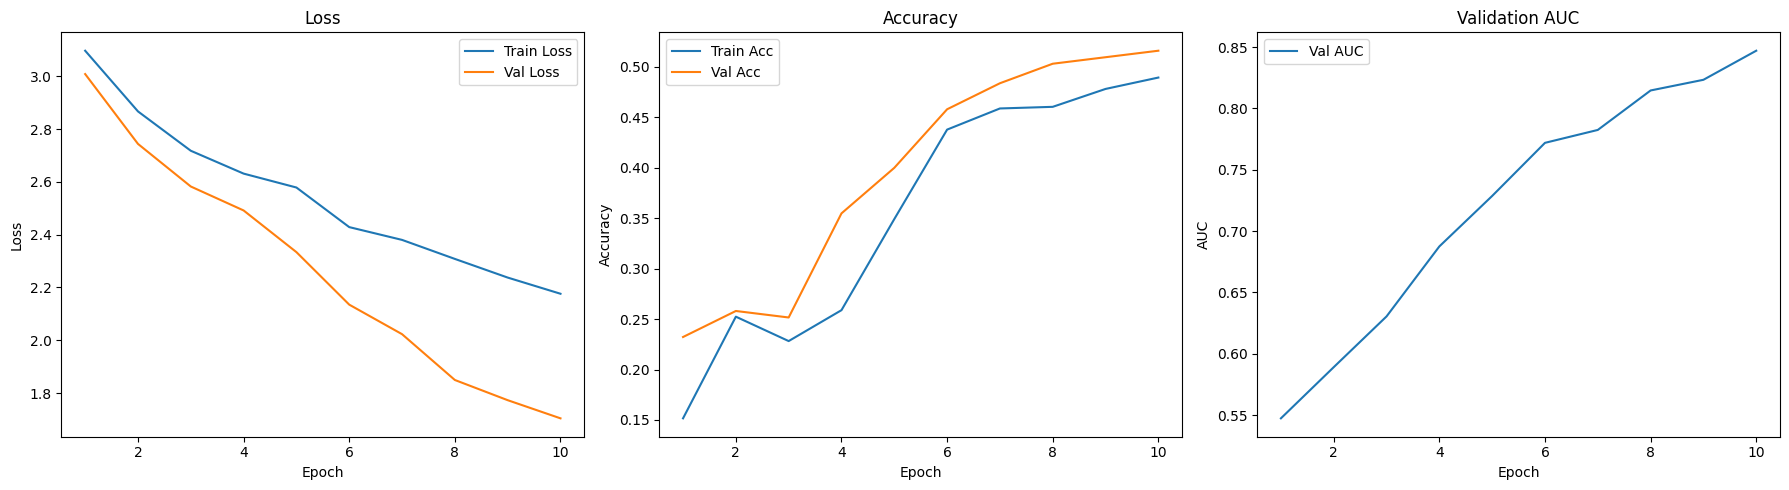

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18672\572754688.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [12]:
train_loader, val_loader, test_loader = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)


model_resnet, history_resnet = train_model_with_plots(
    train_loader,
    val_loader,
    num_classes=len(le.classes_),
    model_name="resnet50",
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_resnet_da.pth"
);





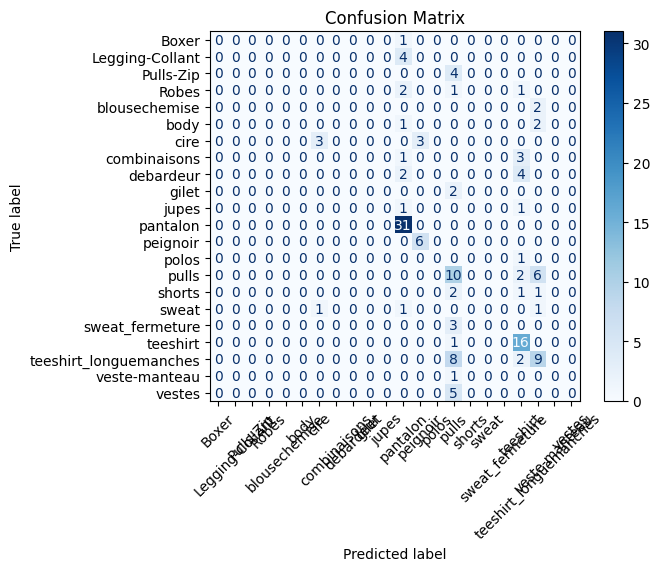

In [13]:


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)

# Utilise la liste des classes dans l'ordre du LabelEncoder
class_names = le.classes_


plot_confusion_matrix(model_resnet, test_loader, class_names=class_names)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="resnet50", batch_size=32)

evaluate_on_test(model_resnet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.75      0.50      0.60         6
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         6
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
          11       0.70      1.00      0.83        31
          12       0.67      1.00      0.80         6
          13       0.00      0.00      0.00         1
          14       0.27      0.56      0.36        18
          15       0.00      0.00      0.00         4
          16       0.00      0.00      0.00         3
 

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

## Vgg16

📿 Using device: cuda
Epoch 1/10 - Train Loss: 2.1954, Val Loss: 1.2279, Train Acc: 47.69%, Val Acc: 65.07%, AUC: 0.9051
📦 Best model saved.
Epoch 2/10 - Train Loss: 1.7674, Val Loss: 0.9944, Train Acc: 64.47%, Val Acc: 68.49%, AUC: 0.9517
📦 Best model saved.
Epoch 3/10 - Train Loss: 1.5630, Val Loss: 0.7566, Train Acc: 74.06%, Val Acc: 77.40%, AUC: 0.9682
📦 Best model saved.
Epoch 4/10 - Train Loss: 1.4230, Val Loss: 0.8515, Train Acc: 80.65%, Val Acc: 76.71%, AUC: 0.9704
Epoch 5/10 - Train Loss: 1.4760, Val Loss: 0.8233, Train Acc: 79.62%, Val Acc: 78.08%, AUC: 0.9455


2025/07/02 14:32:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 6/10 - Train Loss: 1.4659, Val Loss: 0.8158, Train Acc: 79.11%, Val Acc: 75.34%, AUC: 0.9477
⏹️ Early stopping triggered.


2025/07/02 14:32:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/07/02 14:32:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 77.40%


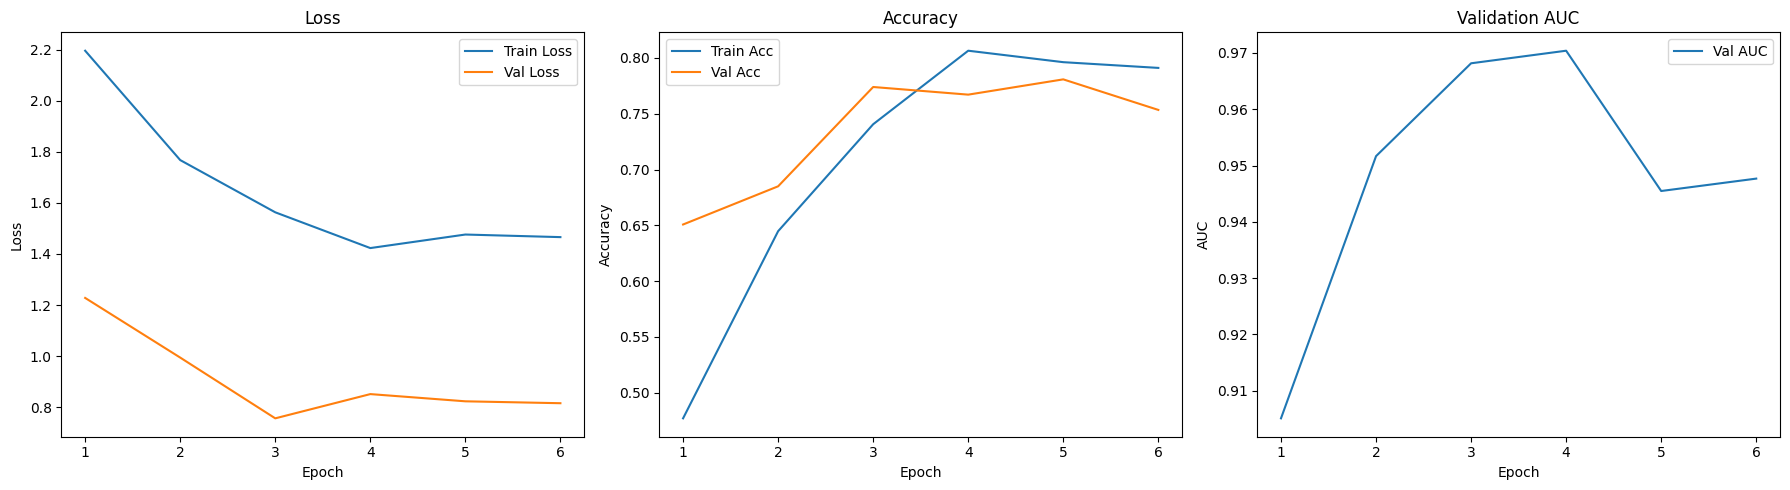

In [15]:
train_loader, val_loader, test_loader = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)



model_vgg16, history_vgg16 = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="vgg16",
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_vgg16_da.pth"
);

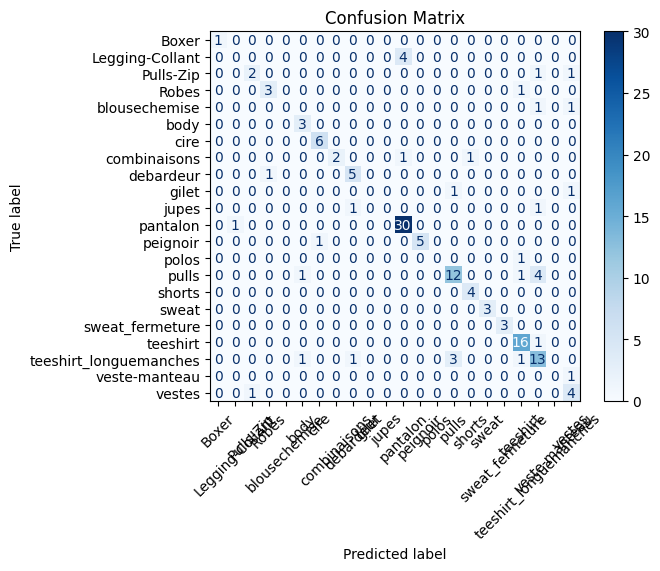

In [16]:
_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)

plot_confusion_matrix(model_vgg16, test_loader, class_names=class_names)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="vgg16", batch_size=32)

evaluate_on_test(model_vgg16, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         4
           2       0.67      0.50      0.57         4
           3       0.75      0.75      0.75         4
           4       0.00      0.00      0.00         2
           5       0.60      1.00      0.75         3
           6       0.86      1.00      0.92         6
           7       1.00      0.50      0.67         4
           8       0.71      0.83      0.77         6
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
          11       0.86      0.97      0.91        31
          12       1.00      0.83      0.91         6
          13       0.00      0.00      0.00         1
          14       0.75      0.67      0.71        18
          15       0.80      1.00      0.89         4
          16       1.00      1.00      1.00         3
 

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

## GoogleNet

📿 Using device: cuda
Epoch 1/10 - Train Loss: 2.6374, Val Loss: 1.3275, Train Acc: 38.10%, Val Acc: 62.33%, AUC: 0.8968
📦 Best model saved.
Epoch 2/10 - Train Loss: 1.7267, Val Loss: 1.0075, Train Acc: 69.52%, Val Acc: 71.23%, AUC: 0.9479
📦 Best model saved.
Epoch 3/10 - Train Loss: 1.6228, Val Loss: 0.8989, Train Acc: 75.94%, Val Acc: 73.29%, AUC: 0.9522
📦 Best model saved.
Epoch 4/10 - Train Loss: 1.5804, Val Loss: 0.9999, Train Acc: 77.65%, Val Acc: 73.29%, AUC: 0.9461
Epoch 5/10 - Train Loss: 1.4613, Val Loss: 0.9151, Train Acc: 82.62%, Val Acc: 73.97%, AUC: 0.9623


2025/07/02 14:37:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/02 14:37:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 6/10 - Train Loss: 1.3423, Val Loss: 0.9512, Train Acc: 85.70%, Val Acc: 73.29%, AUC: 0.9417
⏹️ Early stopping triggered.


2025/07/02 14:37:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 73.29%


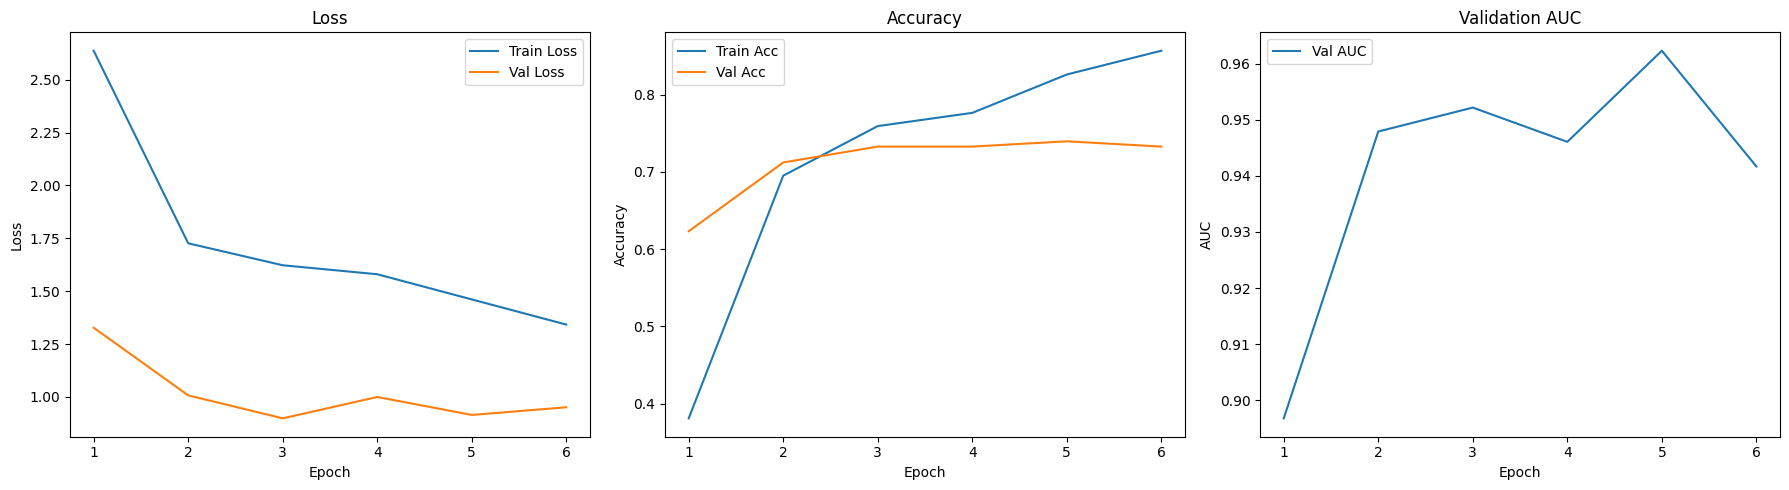

In [ ]:
train_loader, val_loader, test_loader = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)



model_googlenet, history_googlenet = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="inception_v3",
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_googlenet_da.pth"
);

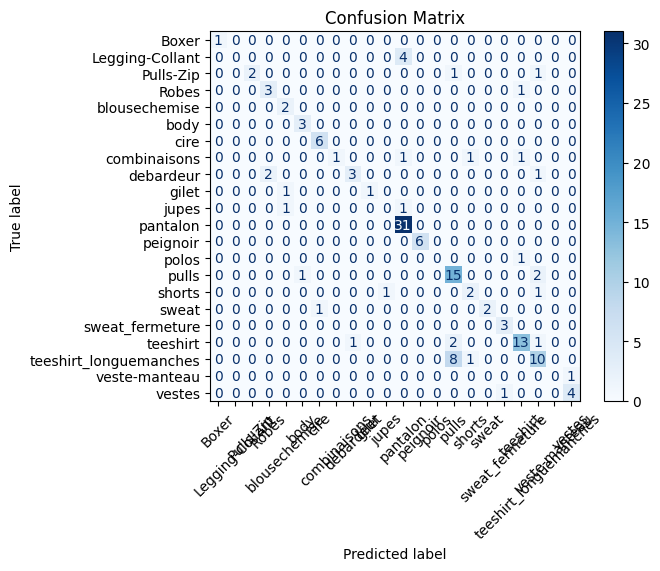

In [19]:
_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)


plot_confusion_matrix(model_googlenet, test_loader, class_names=class_names)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_from_df(idclothes_df, model_name="inception_v3", batch_size=32)

evaluate_on_test(model_googlenet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         4
           2       1.00      0.50      0.67         4
           3       0.60      0.75      0.67         4
           4       0.50      1.00      0.67         2
           5       0.75      1.00      0.86         3
           6       0.86      1.00      0.92         6
           7       1.00      0.50      0.67         4
           8       0.75      0.50      0.60         6
           9       1.00      0.50      0.67         2
          10       0.00      0.00      0.00         2
          11       0.84      1.00      0.91        31
          12       1.00      1.00      1.00         6
          13       0.00      0.00      0.00         1
          14       0.58      0.83      0.68        18
          15       0.50      0.50      0.50         4
          16       1.00      0.67      0.80         3
 

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

def test_random_images_by_category_from_loader(model, test_loader, label_encoder, device, target_label, num_images=6):
    """
    Affiche des images aléatoires d'une catégorie spécifique provenant du test_loader avec prédictions.

    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
        target_label: nom de la catégorie ciblée (ex: 'blousechemise').
        num_images: nombre d'images à afficher.
    """
    model.eval()
    model.to(device)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    target_idx = label_encoder.transform([target_label])[0]

    filtered_images = []
    filtered_labels = []

    # Parcours du loader pour collecter les images correspondant à la catégorie
    for images, labels in test_loader:
        for img, label in zip(images, labels):
            if label.item() == target_idx:
                filtered_images.append(img)
                filtered_labels.append(label)

    if len(filtered_images) == 0:
        print(f"Aucune image trouvée pour la catégorie '{target_label}'.")
        return

    num_images = min(num_images, len(filtered_images))
    selected_indices = random.sample(range(len(filtered_images)), num_images)

    selected_images = torch.stack([filtered_images[i] for i in selected_indices]).to(device)

    with torch.no_grad():
        outputs = model(selected_images)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

    selected_images = selected_images.cpu()
    preds = preds.cpu()
    confidences = confidences.cpu()

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        img = selected_images[i].permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        img_resized = cv2.resize(img, (512, 512))
        img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img_resized)
        plt.axis('off')

        pred_class = label_encoder.inverse_transform([preds[i].item()])[0]
        conf = confidences[i].item()
        plt.title(f"Prédit : {pred_class}\nConf : {conf:.2f}")

    plt.tight_layout()
    plt.show()


In [23]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_resnet = timm.create_model("resnet50", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_resnet_da.pth", map_location=torch.device('cpu'))
model_resnet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

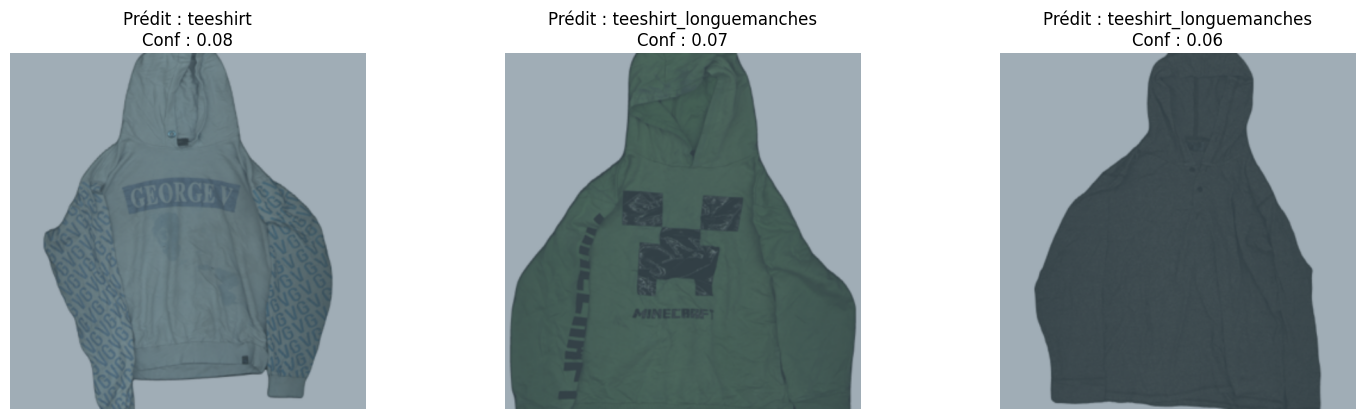

In [24]:
test_random_images_by_category_from_loader(
    model=model_resnet,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="sweat",
    num_images=6
)

In [ ]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_googlenet = timm.create_model("inception_v3", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_googlenet_da.pth", map_location=torch.device('cpu'))
model_googlenet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_googlenet.eval()

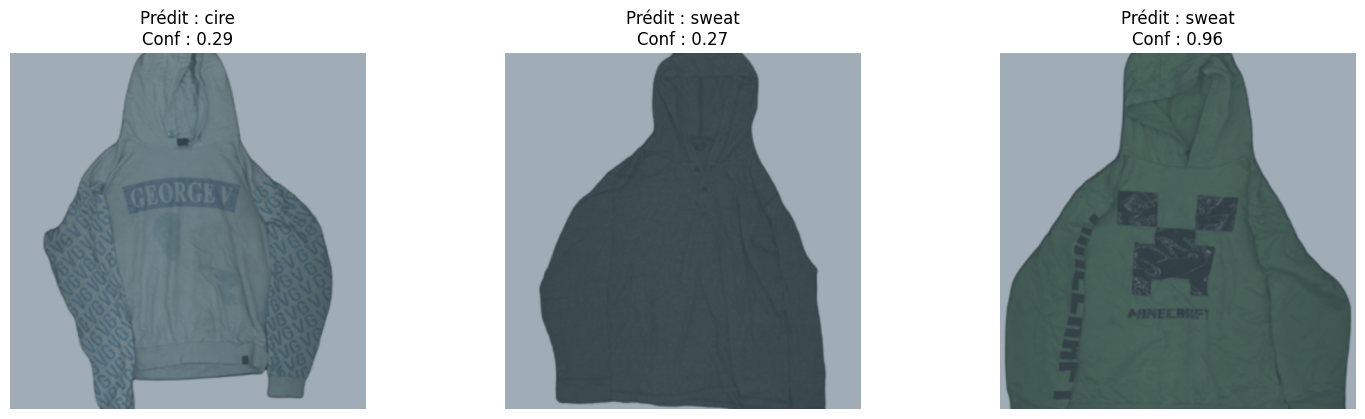

In [25]:
test_random_images_by_category_from_loader(
    model=model_googlenet,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="sweat",
    num_images=6
)

In [ ]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_vgg16 = timm.create_model("vgg16", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_vgg16_da.pth", map_location=torch.device('cpu'))
model_vgg16.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_vgg16.eval()

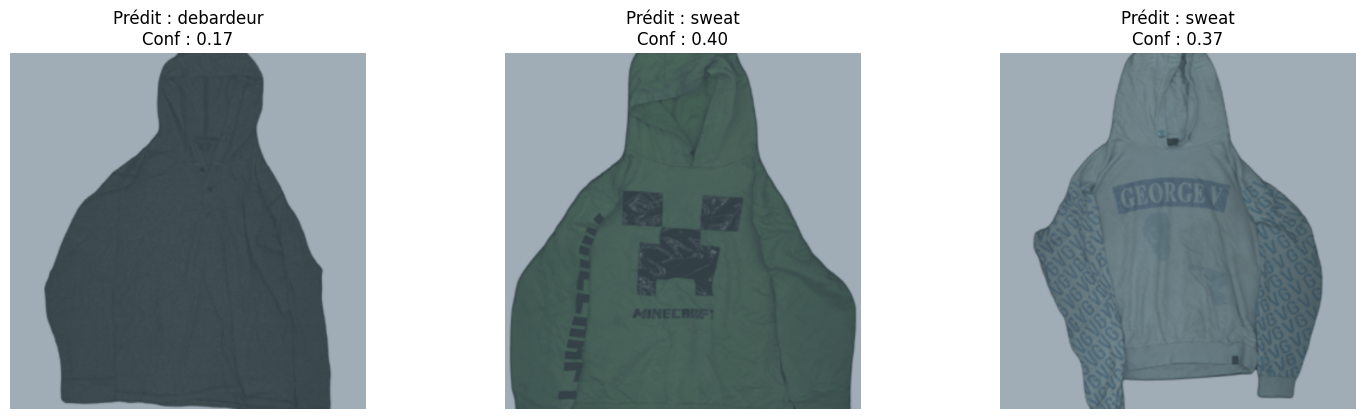

In [26]:
test_random_images_by_category_from_loader(
    model=model_vgg16,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="sweat",
    num_images=6
)

# Data Augmentation (Rotation aléatoire)

In [2]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, resize_size=(512, 512)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.resize_size = resize_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image_path = row["image_path"]
            label = row["labels"]

            image = Image.open(image_path).convert("RGB")

            if image.size != self.resize_size:
                image = image.resize(self.resize_size)

            if self.transform:
                image = self.transform(image)

            # Convert label en tensor Long (pour classification)
            label = torch.tensor(label, dtype=torch.long)

            return image, label


def create_data_loaders_ra_from_df(df, model_name, batch_size=32, train_ratio=0.8, val_ratio=0.1, seed=42):
    model = timm.create_model(model_name, pretrained=True)
    config = resolve_data_config({}, model=model)

    # Transformations spécifiques
    val_test_transform = create_transform(**config)

    # Rotation aléatoire uniquement pour l'entraînement
    train_transform = transforms.Compose([
        transforms.RandomRotation(degrees=30),
        transforms.Resize(config['input_size'][1:]),  # Resize to match model input
        transforms.CenterCrop(config['input_size'][1:]),
        transforms.ToTensor(),
        transforms.Normalize(mean=config['mean'], std=config['std'])
    ])

    # Split stratifié
    df_train, df_tmp = train_test_split(df, train_size=train_ratio, stratify=df["labels"], random_state=seed)
    val_relative = val_ratio / (1 - train_ratio)
    df_val, df_test = train_test_split(df_tmp, train_size=val_relative, stratify=df_tmp["labels"], random_state=seed)

    # Datasets
    train_ds = ImageDataset(df_train, transform=train_transform)
    val_ds   = ImageDataset(df_val, transform=val_test_transform)
    test_ds  = ImageDataset(df_test, transform=val_test_transform)

    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


## Resnet (RA)

📿 Using device: cuda
Epoch 1/10 - Train Loss: 2.2859, Val Loss: 2.1422, Train Acc: 37.90%, Val Acc: 51.61%, AUC: 0.5897
📦 Best model saved.
Epoch 2/10 - Train Loss: 1.9555, Val Loss: 1.8153, Train Acc: 44.68%, Val Acc: 44.52%, AUC: 0.6553
📦 Best model saved.
Epoch 3/10 - Train Loss: 1.8113, Val Loss: 1.6087, Train Acc: 45.73%, Val Acc: 52.26%, AUC: 0.7183
📦 Best model saved.
Epoch 4/10 - Train Loss: 1.7245, Val Loss: 1.4008, Train Acc: 52.02%, Val Acc: 60.00%, AUC: 0.7142
📦 Best model saved.
Epoch 5/10 - Train Loss: 1.6112, Val Loss: 1.1825, Train Acc: 56.94%, Val Acc: 63.23%, AUC: 0.7220
📦 Best model saved.
Epoch 6/10 - Train Loss: 1.5480, Val Loss: 1.0747, Train Acc: 61.05%, Val Acc: 72.26%, AUC: 0.7690
📦 Best model saved.
Epoch 7/10 - Train Loss: 1.4794, Val Loss: 0.9835, Train Acc: 63.95%, Val Acc: 78.06%, AUC: 0.7860
📦 Best model saved.
Epoch 8/10 - Train Loss: 1.4542, Val Loss: 0.8799, Train Acc: 67.34%, Val Acc: 79.35%, AUC: 0.7915
📦 Best model saved.
Epoch 9/10 - Train Loss: 1.

2025/07/16 15:14:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 10/10 - Train Loss: 1.3498, Val Loss: 0.7439, Train Acc: 73.15%, Val Acc: 80.00%, AUC: 0.8818
📦 Best model saved.


2025/07/16 15:14:40 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/07/16 15:14:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 80.00%


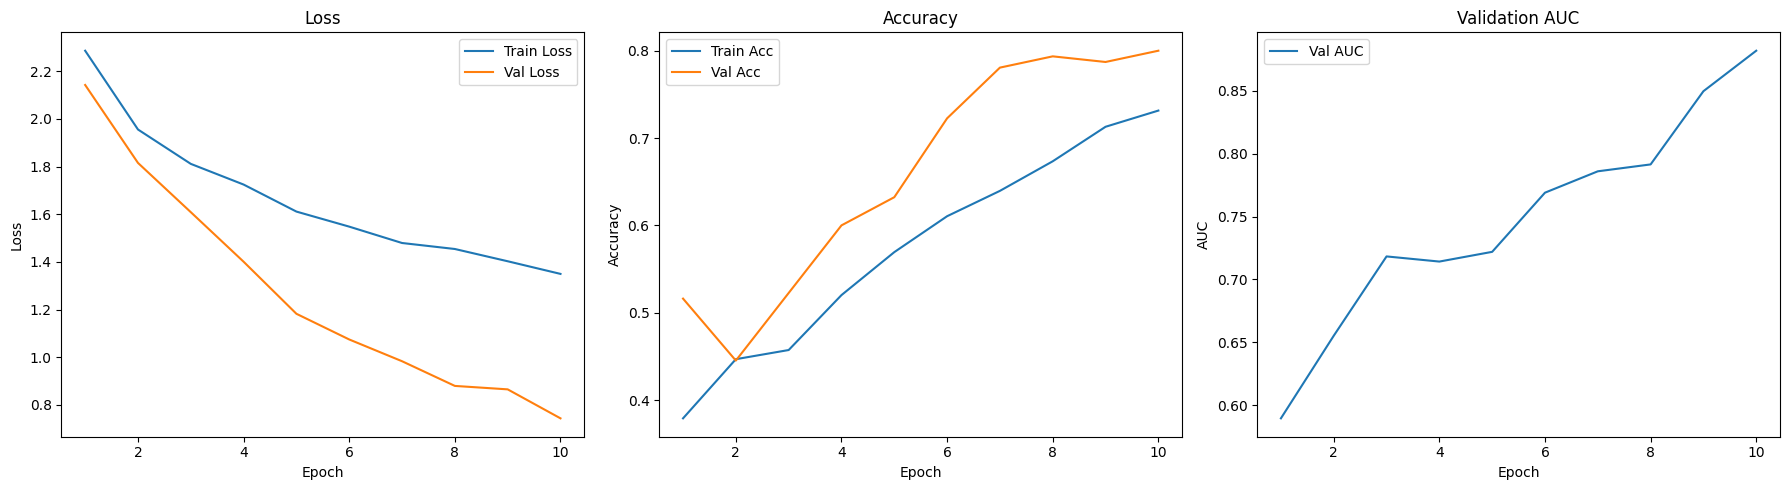

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_19420\572754688.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [18]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="resnet50", batch_size=32)


model_resnet, history_resnet = train_model_with_plots(
    train_loader,
    val_loader,
    num_classes=len(le.classes_),
    model_name="resnet50",
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_resnet_ra.pth"
)





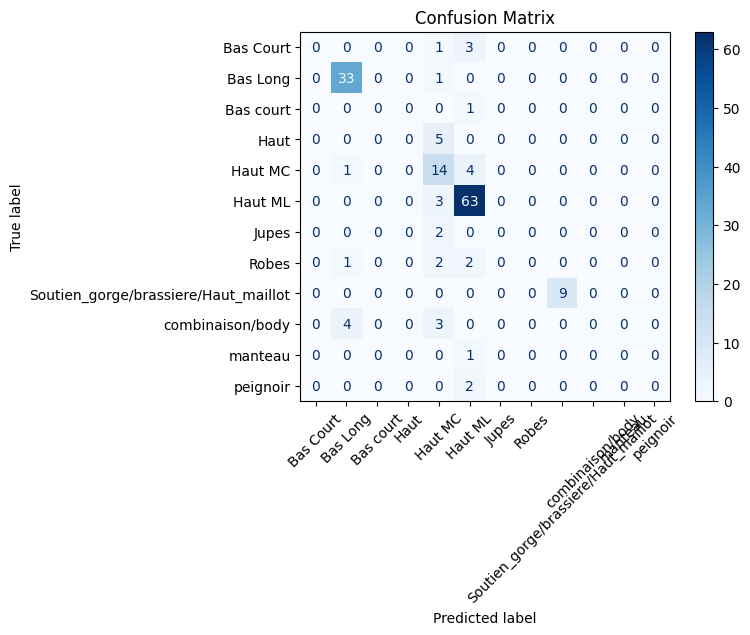

In [19]:


# Utilise la liste des classes dans l'ordre du LabelEncoder
class_names = le.classes_

plot_confusion_matrix(model_resnet, test_loader, class_names=class_names)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="resnet50", batch_size=32)

evaluate_on_test(model_resnet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.85      0.97      0.90        34
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         5
           4       0.45      0.74      0.56        19
           5       0.83      0.95      0.89        66
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         5
           8       1.00      1.00      1.00         9
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         2

    accuracy                           0.77       155
   macro avg       0.26      0.31      0.28       155
weighted avg       0.65      0.77      0.70       155



c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

## Vgg16 (RA)

📿 Using device: cuda
Epoch 1/10 - Train Loss: 2.5699, Val Loss: 1.6096, Train Acc: 34.27%, Val Acc: 53.55%, AUC: 0.8706
📦 Best model saved.
Epoch 2/10 - Train Loss: 2.0708, Val Loss: 1.3024, Train Acc: 52.10%, Val Acc: 61.29%, AUC: 0.9353
📦 Best model saved.
Epoch 3/10 - Train Loss: 1.8891, Val Loss: 1.1150, Train Acc: 57.98%, Val Acc: 67.10%, AUC: 0.9531
📦 Best model saved.
Epoch 4/10 - Train Loss: 1.8770, Val Loss: 0.9978, Train Acc: 61.53%, Val Acc: 72.26%, AUC: 0.9534
📦 Best model saved.
Epoch 5/10 - Train Loss: 1.8818, Val Loss: 1.1334, Train Acc: 65.48%, Val Acc: 69.03%, AUC: 0.9535
Epoch 6/10 - Train Loss: 1.7775, Val Loss: 1.0259, Train Acc: 68.63%, Val Acc: 69.03%, AUC: 0.9658


2025/07/25 15:30:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 7/10 - Train Loss: 1.7191, Val Loss: 1.0521, Train Acc: 69.76%, Val Acc: 72.90%, AUC: 0.9545
⏹️ Early stopping triggered.


2025/07/25 15:30:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/07/25 15:31:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 72.26%


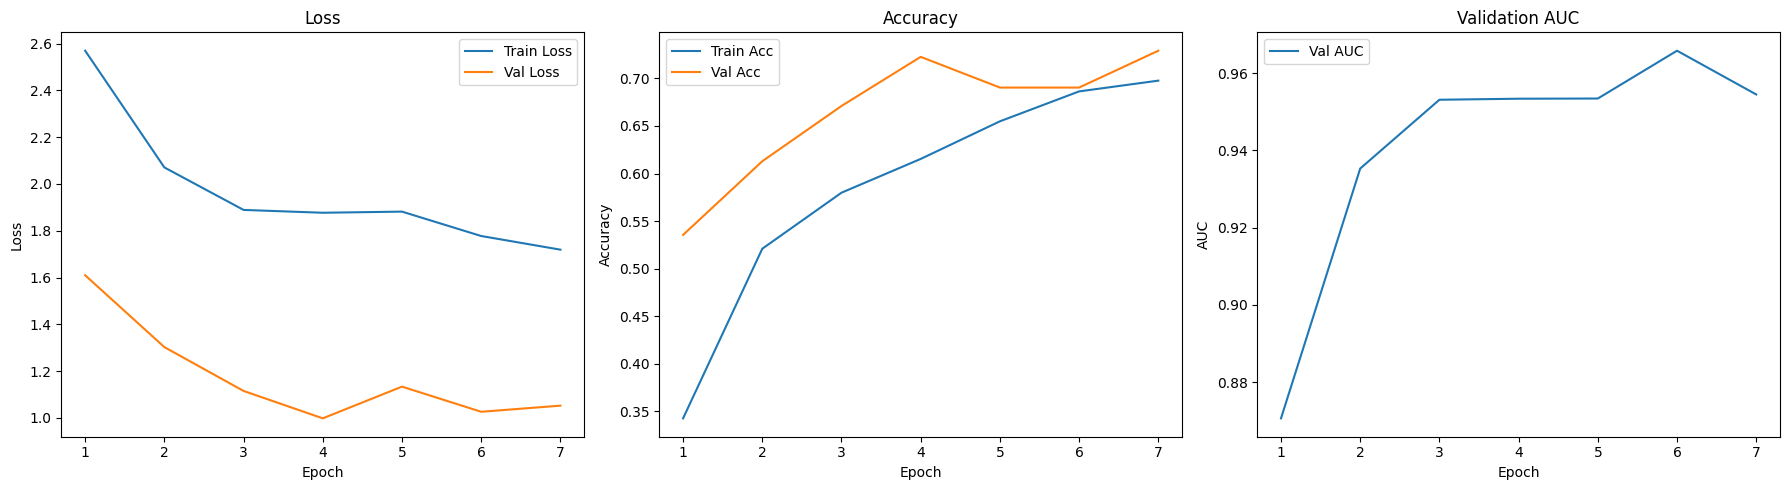

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_17448\572754688.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [43]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="vgg16", batch_size=32)



model_vgg16, history_vgg16 = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="vgg16",
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_vgg16_ra.pth"
);

In [25]:
class_names = le.classes_
print(list(class_names))

['Legging-Collant', 'Pull-Bouton', 'Pulls-Zip', 'Robes', 'blousechemise', 'body', 'boxer_calecon', 'combinaisons', 'debardeur', 'gilet', 'jupes', 'manteau', 'pantalon', 'peignoir', 'polos', 'polos_longues_manches', 'pulls', 'shorts', 'soutien_gorge', 'sweat', 'sweat_fermeture', 'teeshirt', 'teeshirt_longuemanches', 'veste_capuche', 'vestes_col']


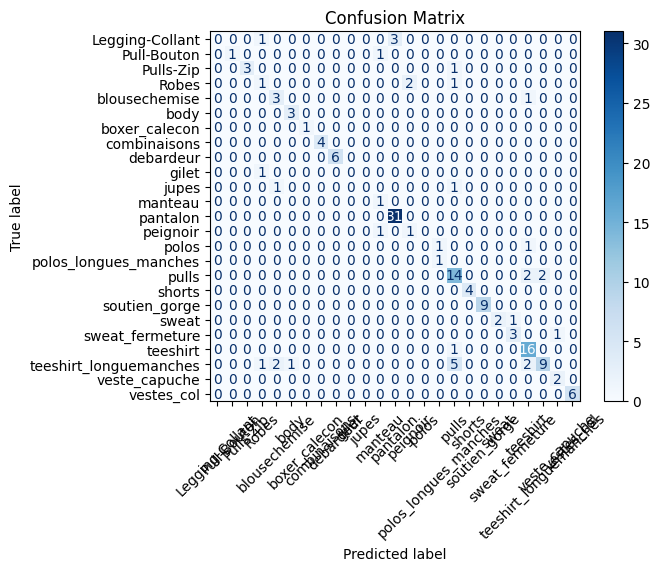

In [24]:
_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="vgg16", batch_size=32)


plot_confusion_matrix(model_vgg16, test_loader, class_names=class_names)

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="vgg16", batch_size=32)

evaluate_on_test(model_vgg16, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       1.00      0.97      0.99        34
           2       0.00      0.00      0.00         1
           3       0.80      0.80      0.80         5
           4       0.80      0.84      0.82        19
           5       0.91      0.92      0.92        66
           6       0.67      1.00      0.80         2
           7       0.75      0.60      0.67         5
           8       1.00      1.00      1.00         9
           9       0.88      1.00      0.93         7
          10       1.00      1.00      1.00         1
          11       0.67      1.00      0.80         2

    accuracy                           0.90       155
   macro avg       0.75      0.78      0.75       155
weighted avg       0.89      0.90      0.89       155



c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

In [ ]:
import os
import torch
import timm
import numpy as np
import cv2
from rembg import remove
from PIL import Image
from torchvision import transforms

# === Paramètres ===
MODEL_PATH = "model/best_model_vgg16_ra.pth"  # <- chemin vers ton fichier .pth
ARCH_NAME = "vgg16"  # <- adapte ce nom selon le modèle utilisé

CLASS_NAMES = ['Legging-Collant', 'Pull-Bouton', 'Pulls-Zip', 'Robes', 'blousechemise', 'body',
               'boxer_calecon', 'combinaisons', 'debardeur', 'gilet', 'jupes', 'manteau', 'pantalon',
               'peignoir', 'polos', 'polos_longues_manches', 'pulls', 'shorts', 'soutien_gorge',
               'sweat', 'sweat_fermeture', 'teeshirt', 'teeshirt_longuemanches', 'veste_capuche', 'vestes_col']

# === Création et chargement du modèle ===
NUM_CLASSES = len(CLASS_NAMES)
model = timm.create_model(ARCH_NAME, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_16536\128495940.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_locat

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [34]:
FOLDER_PATH = "IDclothes_Data/teeshirt"  # <- dossier contenant les images

def get_cntr(seg):
    mask = seg.astype(np.uint8)
    cntrs, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cntrs:
        raise ValueError("Aucun contour trouvé.")
    cntr = max(cntrs, key=cv2.contourArea)
    return np.squeeze(cntr, axis=1)

def process_image_and_return_tensor(img_path, final_size=512):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {img_path}")

    rgba = remove(img)
    alpha = rgba[..., 3]
    _, binary_mask = cv2.threshold(alpha, 127, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)
    binary_mask = cv2.erode(binary_mask, kernel)

    cntr = get_cntr(binary_mask)
    xmin, xmax = np.min(cntr[:, 0]), np.max(cntr[:, 0])
    ymin, ymax = np.min(cntr[:, 1]), np.max(cntr[:, 1])

    cropped_img = rgba[ymin:ymax, xmin:xmax, :3]
    cropped_mask = binary_mask[ymin:ymax, xmin:xmax]

    h, w = cropped_img.shape[:2]
    white_obj = np.ones((h, w, 3), dtype=np.uint8) * 255
    white_obj[cropped_mask.astype(bool)] = cropped_img[cropped_mask.astype(bool)]

    scale = min(final_size / h, final_size / w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized_obj = cv2.resize(white_obj, (new_w, new_h), interpolation=cv2.INTER_AREA)

    final_img = np.ones((final_size, final_size, 3), dtype=np.uint8) * 255
    x_offset = (final_size - new_w) // 2
    y_offset = (final_size - new_h) // 2
    final_img[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_obj

    pil_img = Image.fromarray(final_img)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((512, 512)),  # selon la taille attendue par ton modèle
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    tensor_img = transform(pil_img).unsqueeze(0)
    return tensor_img

def predict_image(img_path, model):
    input_tensor = process_image_and_return_tensor(img_path)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
    return CLASS_NAMES[predicted_class]
image_extensions = (".jpg", ".jpeg", ".png")
image_files = [f for f in os.listdir(FOLDER_PATH) if f.lower().endswith(image_extensions)]

for img_name in image_files:
    img_path = os.path.join(FOLDER_PATH, img_name)
    try:
        pred = predict_image(img_path, model)
        print(f"{img_name} --> {pred}")
    except Exception as e:
        print(f"Erreur avec {img_name} : {e}")


108_jai_standard_1751286293.8889747.png --> teeshirt
109_jai_standard_1751286321.6715996.png --> teeshirt
110_jai_standard_1751286350.9676166.png --> teeshirt
111_jai_standard_1751286367.0139918.png --> teeshirt
112_jai_standard_1751286405.2282345.png --> teeshirt
113_jai_standard_1751286418.5173965.png --> teeshirt
114_jai_standard_1751286440.9337106.png --> debardeur
115_jai_standard_1751286457.353124.png --> pulls
116_jai_standard_1751286473.835678.png --> teeshirt
117_jai_standard_1751286481.0525522.png --> pulls
118_jai_standard_1751286487.411123.png --> teeshirt
119_jai_standard_1751286498.8055947.png --> teeshirt
120_jai_standard_1751286507.8092759.png --> teeshirt
121_jai_standard_1751286516.226023.png --> pulls
122_jai_standard_1751286530.5195265.png --> teeshirt
123_jai_standard_1751286548.709778.png --> pulls
124_jai_standard_1751286563.0656648.png --> teeshirt
125_jai_standard_1751286588.2390099.png --> teeshirt
126_jai_standard_1751286596.9930403.png --> teeshirt
127_jai_s

KeyboardInterrupt: 

## GoogleNet (RA)

📿 Using device: cuda
Epoch 1/10 - Train Loss: 1.6658, Val Loss: 1.1612, Train Acc: 65.65%, Val Acc: 69.68%, AUC: 0.8280
📦 Best model saved.
Epoch 2/10 - Train Loss: 1.2895, Val Loss: 0.6698, Train Acc: 77.90%, Val Acc: 85.16%, AUC: 0.9135
📦 Best model saved.
Epoch 3/10 - Train Loss: 1.2101, Val Loss: 0.7584, Train Acc: 80.16%, Val Acc: 85.16%, AUC: 0.9258
Epoch 4/10 - Train Loss: 1.1665, Val Loss: 0.6109, Train Acc: 83.55%, Val Acc: 88.39%, AUC: 0.9352
📦 Best model saved.
Epoch 5/10 - Train Loss: 1.1189, Val Loss: 0.5217, Train Acc: 85.89%, Val Acc: 87.10%, AUC: 0.9248
📦 Best model saved.
Epoch 6/10 - Train Loss: 1.1389, Val Loss: 0.6484, Train Acc: 86.29%, Val Acc: 85.16%, AUC: 0.9176
Epoch 7/10 - Train Loss: 1.0551, Val Loss: 0.5742, Train Acc: 88.71%, Val Acc: 86.45%, AUC: 0.9317


2025/07/16 15:20:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/16 15:20:58 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 8/10 - Train Loss: 1.1809, Val Loss: 0.5704, Train Acc: 82.74%, Val Acc: 87.74%, AUC: 0.9341
⏹️ Early stopping triggered.


2025/07/16 15:21:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 87.10%


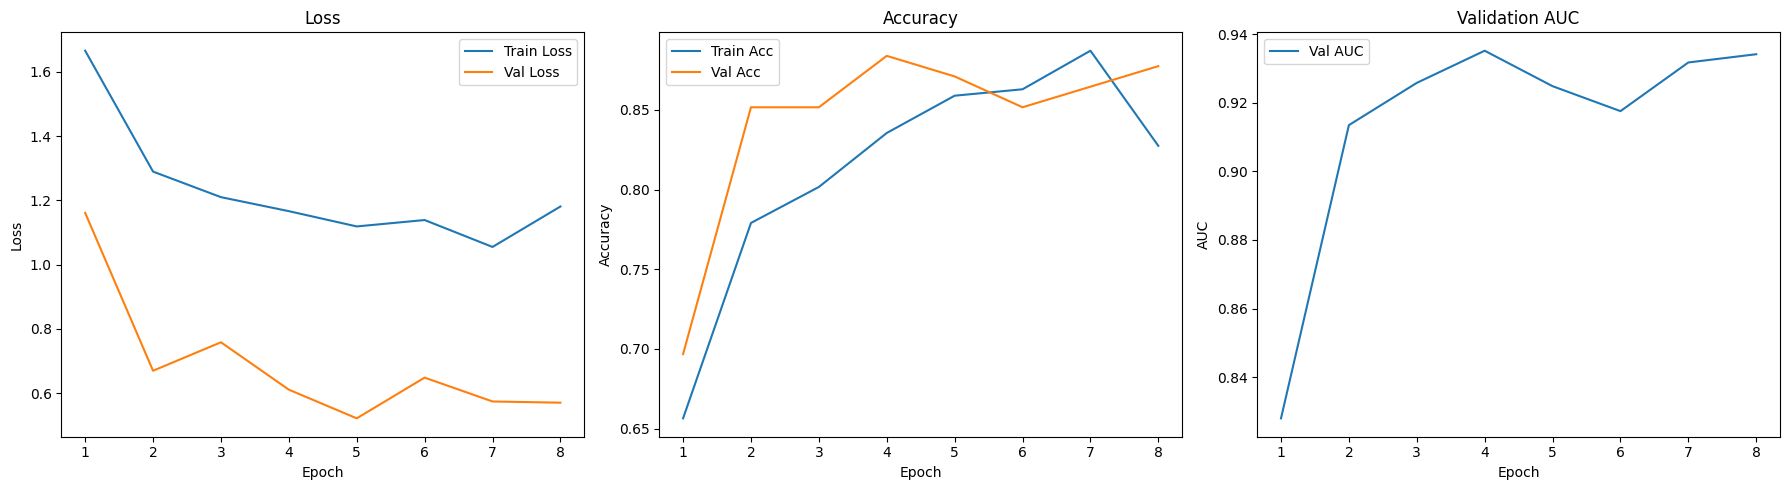

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_19420\572754688.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [24]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="inception_v3", batch_size=32)



model_googlenet, history_googlenet = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="inception_v3",
    num_epochs=10,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_googlenet_ra.pth"
);

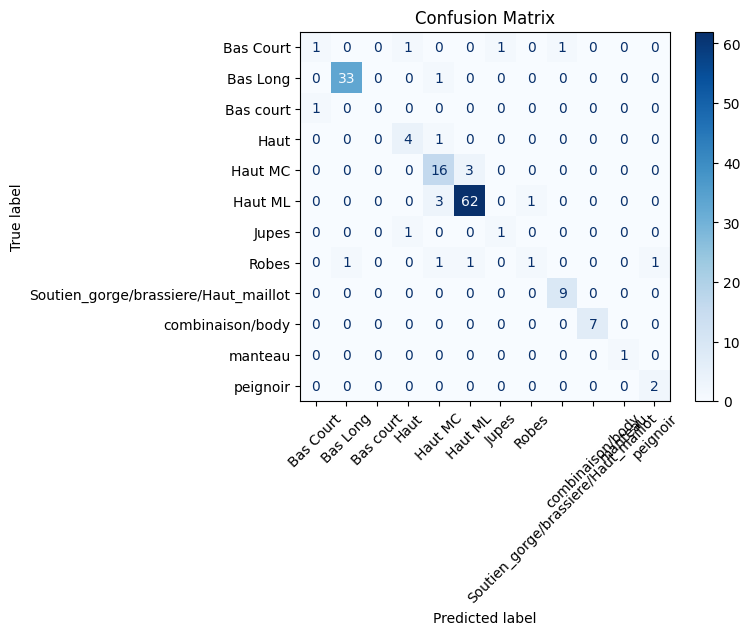

In [26]:
_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="inception_v3", batch_size=32)
# _, val_loader,_ = create_data_loaders_ra_from_df(idclothes_df, model_name="inception_v3", batch_size=32)
#train_loader,_,_ = create_data_loaders_ra_from_df(idclothes_df, model_name="inception_v3", batch_size=32)
plot_confusion_matrix(model_googlenet, test_loader, class_names=class_names)

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df, model_name="inception_v3", batch_size=32)

evaluate_on_test(model_googlenet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.97      0.97      0.97        34
           2       0.00      0.00      0.00         1
           3       0.67      0.80      0.73         5
           4       0.73      0.84      0.78        19
           5       0.94      0.94      0.94        66
           6       0.50      0.50      0.50         2
           7       0.50      0.20      0.29         5
           8       0.90      1.00      0.95         9
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00         1
          11       0.67      1.00      0.80         2

    accuracy                           0.88       155
   macro avg       0.70      0.71      0.69       155
weighted avg       0.87      0.88      0.87       155



c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

In [28]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

def test_random_images_by_category_from_loader(model, test_loader, label_encoder, device, target_label, num_images=6):
    """
    Affiche des images aléatoires d'une catégorie spécifique provenant du test_loader avec prédictions.

    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
        target_label: nom de la catégorie ciblée (ex: 'blousechemise').
        num_images: nombre d'images à afficher.
    """
    model.eval()
    model.to(device)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    target_idx = label_encoder.transform([target_label])[0]

    filtered_images = []
    filtered_labels = []

    # Parcours du loader pour collecter les images correspondant à la catégorie
    for images, labels in test_loader:
        for img, label in zip(images, labels):
            if label.item() == target_idx:
                filtered_images.append(img)
                filtered_labels.append(label)

    if len(filtered_images) == 0:
        print(f"Aucune image trouvée pour la catégorie '{target_label}'.")
        return

    num_images = min(num_images, len(filtered_images))
    selected_indices = random.sample(range(len(filtered_images)), num_images)

    selected_images = torch.stack([filtered_images[i] for i in selected_indices]).to(device)

    with torch.no_grad():
        outputs = model(selected_images)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

    selected_images = selected_images.cpu()
    preds = preds.cpu()
    confidences = confidences.cpu()

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        img = selected_images[i].permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        img_resized = cv2.resize(img, (512, 512))
        img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img_resized)
        plt.axis('off')

        pred_class = label_encoder.inverse_transform([preds[i].item()])[0]
        conf = confidences[i].item()
        plt.title(f"Prédit : {pred_class}\nConf : {conf:.2f}")

    plt.tight_layout()
    plt.show()


In [29]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_resnet = timm.create_model("resnet50", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_resnet_ra.pth", map_location=torch.device('cpu'))
model_resnet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_resnet.eval()


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_19420\1101999430.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_resnet_ra.pt

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

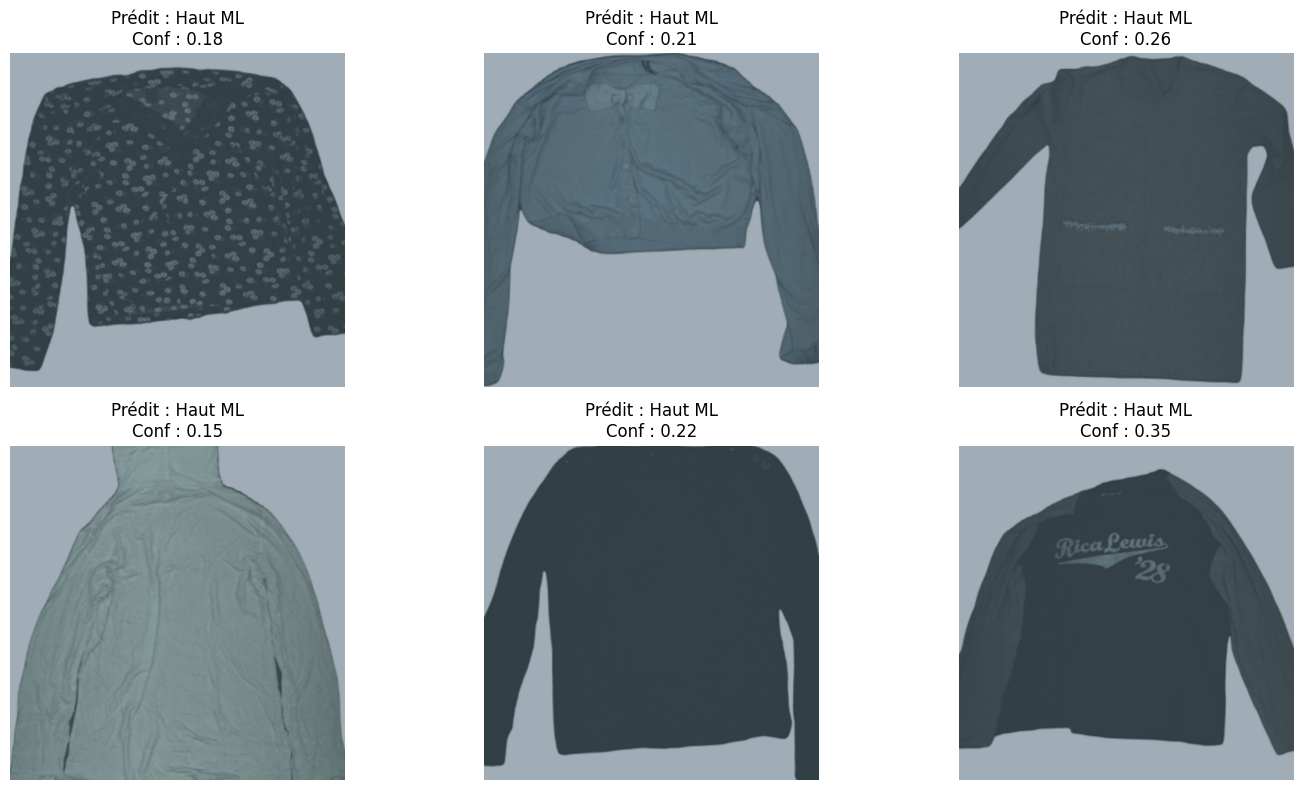

['Haut ML', 'Haut ML', 'Haut ML', 'Haut ML', 'Haut ML', 'Haut ML']

In [40]:
test_random_images_by_category_from_loader(
    model=model_resnet,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="Haut ML",
    num_images=6
)


In [31]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_vgg16 = timm.create_model("vgg16", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_vgg16_ra.pth", map_location=torch.device('cpu'))
model_vgg16.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_vgg16.eval()


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_19420\2187357906.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_vgg16_ra.pth

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

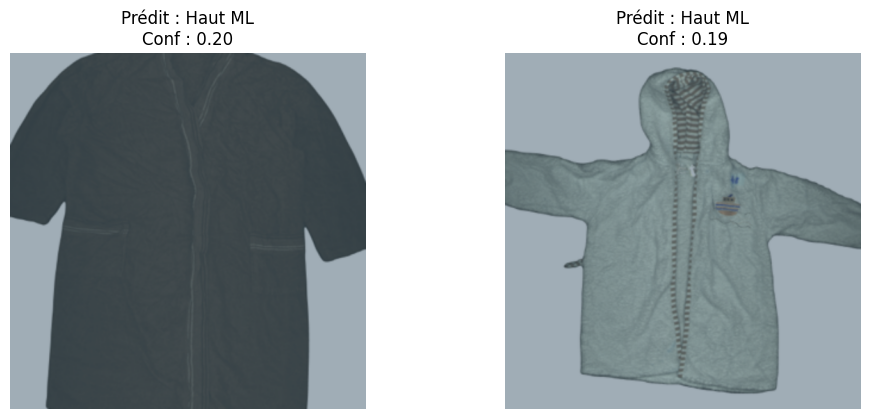

In [32]:
test_random_images_by_category_from_loader(
    model=model_vgg16,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="peignoir",
    num_images=6
)


In [33]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_googlenet = timm.create_model("inception_v3", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_googlenet_ra.pth", map_location=torch.device('cpu'))
model_googlenet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_googlenet.eval()


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_19420\3892042692.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_googlenet_ra

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [34]:
def test_random_images_by_category_from_loader(model, test_loader, label_encoder, device, target_label, num_images=6):
    """
    Affiche des images aléatoires d'une catégorie spécifique provenant du test_loader avec prédictions.
    Retourne la liste des noms de classes prédites.

    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
        target_label: nom de la catégorie ciblée (ex: 'blousechemise').
        num_images: nombre d'images à afficher.

    Returns:
        predicted_classes (list): noms des classes prédites.
    """
    model.eval()
    model.to(device)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    target_idx = label_encoder.transform([target_label])[0]

    filtered_images = []
    filtered_labels = []

    # Parcours du loader pour collecter les images correspondant à la catégorie
    for images, labels in test_loader:
        for img, label in zip(images, labels):
            if label.item() == target_idx:
                filtered_images.append(img)
                filtered_labels.append(label)

    if len(filtered_images) == 0:
        print(f"Aucune image trouvée pour la catégorie '{target_label}'.")
        return []

    num_images = min(num_images, len(filtered_images))
    selected_indices = random.sample(range(len(filtered_images)), num_images)

    selected_images = torch.stack([filtered_images[i] for i in selected_indices]).to(device)

    with torch.no_grad():
        outputs = model(selected_images)
        probs = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, dim=1)

    selected_images = selected_images.cpu()
    preds = preds.cpu()
    confidences = confidences.cpu()

    predicted_classes = []

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        img = selected_images[i].permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)

        img_resized = cv2.resize(img, (512, 512))
        img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img_resized)
        plt.axis('off')

        pred_class = label_encoder.inverse_transform([preds[i].item()])[0]
        conf = confidences[i].item()
        predicted_classes.append(pred_class)

        plt.title(f"Prédit : {pred_class}\nConf : {conf:.2f}")

    plt.tight_layout()
    plt.show()

    return predicted_classes


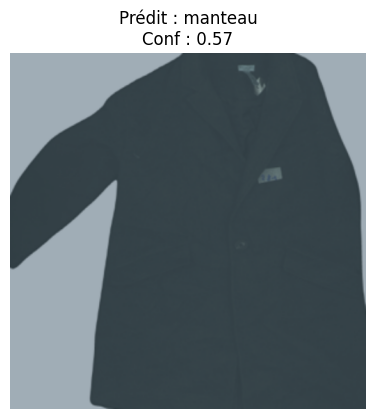

['manteau']

In [45]:
test_random_images_by_category_from_loader(
    model=model_googlenet,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="manteau",
    num_images=6
)


In [94]:
def analyze_wrong_predictions_by_class(model, test_loader, label_encoder, device, target_label, num_images=100):
    """
    Analyse les erreurs de prédiction du modèle sur des images de la classe spécifiée.
    
    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
        target_label: nom de la catégorie ciblée (ex: 'blousechemise').
        num_images: nombre d'images à tester au maximum.

    Returns:
        erreur_stats (dict): dictionnaire contenant les mauvaises prédictions {classe_prédite: nb d'occurrences}
    """
    model.eval()
    model.to(device)

    target_idx = label_encoder.transform([target_label])[0]

    filtered_images = []

    # Collecte des images de la classe cible
    for images, labels in test_loader:
        for img, label in zip(images, labels):
            if label.item() == target_idx:
                filtered_images.append(img)
            if len(filtered_images) >= num_images:
                break
        if len(filtered_images) >= num_images:
            break

    if len(filtered_images) == 0:
        print(f"Aucune image trouvée pour la catégorie '{target_label}'.")
        return {}

    selected_images = torch.stack(filtered_images).to(device)

    with torch.no_grad():
        outputs = model(selected_images)
        preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)

    preds = preds.cpu()

    erreur_stats = {}
    total_erreurs = 0

    for pred in preds:
        pred_class = label_encoder.inverse_transform([pred.item()])[0]
        if pred_class != target_label:
            erreur_stats[pred_class] = erreur_stats.get(pred_class, 0) + 1
            total_erreurs += 1

    if total_erreurs == 0:
        print(f"\n✅ Aucune erreur de prédiction pour la classe '{target_label}'.")
    else:
        print(f"\n🛑 Erreurs de prédiction pour la classe '{target_label}':")
        for classe, count in sorted(erreur_stats.items(), key=lambda x: x[1], reverse=True):
            pourcentage = (count / total_erreurs) * 100
            print(f"  → {classe} : {count} fois ({pourcentage:.1f}%)")

    return erreur_stats


In [99]:
classes = ['Legging-Collant','Pull-Bouton', 'Pulls-Zip', 'Robes' , 'blousechemise', 'body', 'combinaisons', 'debardeur','jupes', 'gilet', 'pantalon',  'peignoir', 'polos', 'polos_longues_manches','pulls' ,  'shorts', 'sweat', 'teeshirt_longuemanches', 'veste_capuche', 'vestes_col']
for cls in classes:
    analyze_wrong_predictions_by_class(
        model_googlenet,
        test_loader,
        label_encoder=le,
        device=device,
        target_label=cls,  # la vraie classe
        num_images=100
    )



🛑 Erreurs de prédiction pour la classe 'Legging-Collant':
  → pantalon : 2 fois (66.7%)
  → Robes : 1 fois (33.3%)

🛑 Erreurs de prédiction pour la classe 'Pull-Bouton':
  → blousechemise : 1 fois (100.0%)

🛑 Erreurs de prédiction pour la classe 'Pulls-Zip':
  → vestes_col : 2 fois (66.7%)
  → teeshirt_longuemanches : 1 fois (33.3%)

🛑 Erreurs de prédiction pour la classe 'Robes':
  → teeshirt_longuemanches : 2 fois (66.7%)
  → debardeur : 1 fois (33.3%)

🛑 Erreurs de prédiction pour la classe 'blousechemise':
  → Pull-Bouton : 1 fois (33.3%)
  → teeshirt : 1 fois (33.3%)
  → teeshirt_longuemanches : 1 fois (33.3%)

🛑 Erreurs de prédiction pour la classe 'body':
  → blousechemise : 1 fois (100.0%)

🛑 Erreurs de prédiction pour la classe 'combinaisons':
  → teeshirt : 1 fois (50.0%)
  → soutien_gorge : 1 fois (50.0%)

🛑 Erreurs de prédiction pour la classe 'debardeur':
  → teeshirt : 1 fois (100.0%)

🛑 Erreurs de prédiction pour la classe 'jupes':
  → shorts : 1 fois (50.0%)
  → teeshi

In [36]:
import torch
import torch.nn.functional as F

def evaluate_model_per_category_from_loader(model, test_loader, label_encoder, device):
    """
    Évalue le modèle sur chaque catégorie présente dans le test_loader,
    affiche la précision par catégorie.

    Args:
        model: modèle entraîné.
        test_loader: DataLoader PyTorch.
        label_encoder: Encodage des labels.
        device: 'cuda' ou 'cpu'.
    """
    model.eval()
    model.to(device)

    num_classes = len(label_encoder.classes_)
    correct_per_class = [0] * num_classes
    total_per_class = [0] * num_classes

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for true_label, pred_label in zip(labels, preds):
                total_per_class[true_label.item()] += 1
                if true_label.item() == pred_label.item():
                    correct_per_class[true_label.item()] += 1

    print("\n📊 Résultats par catégorie :\n")
    for idx, class_name in enumerate(label_encoder.classes_):
        total = total_per_class[idx]
        correct = correct_per_class[idx]
        accuracy = (correct / total * 100) if total > 0 else 0
        print(f"✅ Classe '{class_name}': {correct}/{total} images correctement classées ({accuracy:.2f}%)")


In [37]:
evaluate_model_per_category_from_loader(
    model=model_googlenet,
    test_loader=test_loader,
    label_encoder=le,
    device=device
)



📊 Résultats par catégorie :

✅ Classe 'Bas Court': 1/4 images correctement classées (25.00%)
✅ Classe 'Bas Long': 33/34 images correctement classées (97.06%)
✅ Classe 'Bas court': 0/1 images correctement classées (0.00%)
✅ Classe 'Haut': 4/5 images correctement classées (80.00%)
✅ Classe 'Haut MC': 16/19 images correctement classées (84.21%)
✅ Classe 'Haut ML': 62/66 images correctement classées (93.94%)
✅ Classe 'Jupes': 1/2 images correctement classées (50.00%)
✅ Classe 'Robes': 1/5 images correctement classées (20.00%)
✅ Classe 'Soutien_gorge/brassiere/Haut_maillot': 9/9 images correctement classées (100.00%)
✅ Classe 'combinaison/body': 7/7 images correctement classées (100.00%)
✅ Classe 'manteau': 1/1 images correctement classées (100.00%)
✅ Classe 'peignoir': 2/2 images correctement classées (100.00%)


In [38]:
evaluate_model_per_category_from_loader(
    model=model_resnet,
    test_loader=test_loader,
    label_encoder=le,
    device=device
)


📊 Résultats par catégorie :

✅ Classe 'Bas Court': 0/4 images correctement classées (0.00%)
✅ Classe 'Bas Long': 32/34 images correctement classées (94.12%)
✅ Classe 'Bas court': 0/1 images correctement classées (0.00%)
✅ Classe 'Haut': 0/5 images correctement classées (0.00%)
✅ Classe 'Haut MC': 15/19 images correctement classées (78.95%)
✅ Classe 'Haut ML': 63/66 images correctement classées (95.45%)
✅ Classe 'Jupes': 0/2 images correctement classées (0.00%)
✅ Classe 'Robes': 0/5 images correctement classées (0.00%)
✅ Classe 'Soutien_gorge/brassiere/Haut_maillot': 4/9 images correctement classées (44.44%)
✅ Classe 'combinaison/body': 0/7 images correctement classées (0.00%)
✅ Classe 'manteau': 0/1 images correctement classées (0.00%)
✅ Classe 'peignoir': 0/2 images correctement classées (0.00%)


In [39]:
evaluate_model_per_category_from_loader(
    model=model_vgg16,
    test_loader=test_loader,
    label_encoder=le,
    device=device
)


📊 Résultats par catégorie :

✅ Classe 'Bas Court': 0/4 images correctement classées (0.00%)
✅ Classe 'Bas Long': 31/34 images correctement classées (91.18%)
✅ Classe 'Bas court': 0/1 images correctement classées (0.00%)
✅ Classe 'Haut': 3/5 images correctement classées (60.00%)
✅ Classe 'Haut MC': 13/19 images correctement classées (68.42%)
✅ Classe 'Haut ML': 58/66 images correctement classées (87.88%)
✅ Classe 'Jupes': 0/2 images correctement classées (0.00%)
✅ Classe 'Robes': 0/5 images correctement classées (0.00%)
✅ Classe 'Soutien_gorge/brassiere/Haut_maillot': 3/9 images correctement classées (33.33%)
✅ Classe 'combinaison/body': 6/7 images correctement classées (85.71%)
✅ Classe 'manteau': 0/1 images correctement classées (0.00%)
✅ Classe 'peignoir': 0/2 images correctement classées (0.00%)


In [20]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_vgg16 = timm.create_model("vgg16", pretrained=False, num_classes=25)

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_vgg16_ra.pth", map_location=torch.device('cpu'))
model_vgg16.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_vgg16.eval()

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_16536\497134100.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_vgg16_ra.pth"

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [21]:
import torch

# Exemple d'entrée pour le traçage (même taille que celle attendue par ton modèle)
example_input = torch.randn(1, 3, 512, 512)

# Tracer le modèle
traced_model = torch.jit.trace(model_vgg16, example_input)

# Sauvegarder le modèle torchscripté
traced_model.save("model/torchscript_vgg16.pt")

print("Modèle TorchScript sauvegardé avec succès.")

c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\timm\models\vgg.py:77: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-2] < self.input_kernel_size or x.shape[-1] < self.input_kernel_size:


Modèle TorchScript sauvegardé avec succès.


In [6]:
# Recréer le modèle vide (comme lors de l'entraînement)
import torch
import timm


model_googlenet = timm.create_model("inception_v3", pretrained=False, num_classes=12)

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_googlenet_ra.pth", map_location=torch.device('cpu'))
model_googlenet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_googlenet.eval()

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_23236\3759207478.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model/best_model_googlenet_ra

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [7]:
import torch

# Exemple d'entrée pour le traçage (même taille que celle attendue par ton modèle)
example_input = torch.randn(1, 3, 512, 512)

# Tracer le modèle
traced_model = torch.jit.trace(model_googlenet, example_input)

# Sauvegarder le modèle torchscripté
traced_model.save("model/torchscript_googlenet.pt")

print("Modèle TorchScript sauvegardé avec succès.")


Modèle TorchScript sauvegardé avec succès.


# Test modeles

In [ ]:
# Recréer le modèle vide (comme lors de l'entraînement)
import timm
model_resnet = timm.create_model("vgg16", pretrained=False, num_classes=len(le.classes_))

# Charger les poids en forçant sur le CPU
state_dict = torch.load("model/best_model_vgg16_ra.pth", map_location=torch.device('cpu'))
model_resnet.load_state_dict(state_dict)

# Mettre le modèle en mode évaluation
model_resnet.eval()



In [ ]:
test_random_images_by_category_from_loader(
    model=model_vgg16,
    test_loader=test_loader,
    label_encoder=le,
    device=device,
    target_label="sensorhub",
    num_images=6
)

#   Data Client

In [12]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


2.5.1+cu121
12.1
True
1
NVIDIA RTX A5000


In [13]:
# Extensions d'image à prendre en compte
extensions_valides = (".png")

# Dossier racine
dossier_source = "vetement_client"

# Parcours récursif
for root, dirs, files in os.walk(dossier_source):
    nb_images = sum(1 for f in files if f.lower().endswith(extensions_valides))
    
    if nb_images > 0:
        print(f"{root} : {nb_images} image(s)")

vetement_client\blouse_chemise : 28 image(s)
vetement_client\combinaison : 97 image(s)
vetement_client\doudoune : 39 image(s)
vetement_client\gilet : 95 image(s)
vetement_client\hauts : 78 image(s)
vetement_client\jupes : 86 image(s)
vetement_client\manteau : 101 image(s)
vetement_client\pantalon : 114 image(s)
vetement_client\polos : 31 image(s)
vetement_client\pulls : 79 image(s)
vetement_client\robes : 104 image(s)
vetement_client\short : 85 image(s)
vetement_client\sweat : 98 image(s)
vetement_client\teeshirt : 111 image(s)
vetement_client\veste : 106 image(s)


In [14]:
import os
import pandas as pd

def create_image_dataframe(root_dir, extensions=[".png"]):
    """
    Parcourt le dossier root_dir et ses sous-dossiers, et crée un DataFrame
    avec colonnes 'image_path' et 'label' (nom du sous-dossier).
    """
    data = []
    for subdir, dirs, files in os.walk(root_dir):
        label = os.path.basename(subdir)  # nom du sous-dossier = label
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                path = os.path.join(subdir, file)
                data.append({"image_path": path, "label": label})

    df = pd.DataFrame(data)
    return df

# Exemple d'utilisation
root_folder = "vetement_client"
df_images = create_image_dataframe(root_folder)
print(df_images.head())

# Tu peux aussi sauvegarder dans un CSV si tu veux
df_images.to_csv("image_paths_labels_client.csv", index=False)


                                          image_path           label
0  vetement_client\blouse_chemise\102_jai_standar...  blouse_chemise
1  vetement_client\blouse_chemise\13_jai_standard...  blouse_chemise
2  vetement_client\blouse_chemise\14_jai_standard...  blouse_chemise
3  vetement_client\blouse_chemise\1_jai_standard_...  blouse_chemise
4  vetement_client\blouse_chemise\21_jai_standard...  blouse_chemise


In [15]:
import pandas as pd

idclothes_df_client = pd.read_csv('image_paths_labels_client.csv')
idclothes_df_client.shape

(1252, 2)

In [16]:
from sklearn.preprocessing import LabelEncoder

# Création du LabelEncoder
le = LabelEncoder()

idclothes_df_client["labels"] = le.fit_transform(idclothes_df_client["label"])
num_classes = len(le.classes_)

In [17]:
num_classes

15

In [18]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, resize_size=(512, 512)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.resize_size = resize_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image_path = row["image_path"]
            label = row["labels"]

            image = Image.open(image_path).convert("RGB")

            if image.size != self.resize_size:
                image = image.resize(self.resize_size)

            if self.transform:
                image = self.transform(image)

            # Convert label en tensor Long (pour classification)
            label = torch.tensor(label, dtype=torch.long)

            return image, label


def create_data_loaders_ra_from_df(df, model_name, batch_size=32, train_ratio=0.8, val_ratio=0.1, seed=42):
    model = timm.create_model(model_name, pretrained=True)
    config = resolve_data_config({}, model=model)

    # Transformations spécifiques
    val_test_transform = create_transform(**config)

    # Rotation aléatoire uniquement pour l'entraînement
    train_transform = transforms.Compose([
        transforms.RandomRotation(degrees=30),
        transforms.Resize(config['input_size'][1:]),  # Resize to match model input
        transforms.CenterCrop(config['input_size'][1:]),
        transforms.ToTensor(),
        transforms.Normalize(mean=config['mean'], std=config['std'])
    ])

    # Split stratifié
    df_train, df_tmp = train_test_split(df, train_size=train_ratio, stratify=df["labels"], random_state=seed)
    val_relative = val_ratio / (1 - train_ratio)
    df_val, df_test = train_test_split(df_tmp, train_size=val_relative, stratify=df_tmp["labels"], random_state=seed)

    # Datasets
    train_ds = ImageDataset(df_train, transform=train_transform)
    val_ds   = ImageDataset(df_val, transform=val_test_transform)
    test_ds  = ImageDataset(df_test, transform=val_test_transform)

    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [19]:
def train_model_with_plots(
    train_loader,
    val_loader,
    num_classes,
    model_name,
    num_epochs=10,
    lr=1e-4,
    device=None,
    early_stopping_patience=None,
    mixup_fn=None,
    best_model_path= "./model/best_model.pth"
):

    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("classification_vetements data augmentation")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📿 Using device: {device}")

    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_val_acc = 0.0
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_auc": []
    }

    with mlflow.start_run(run_name=f"{model_name}_run"):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("lr", lr)
        mlflow.log_param("epochs", num_epochs)

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0
            


            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
            
                # ⚡ Skip les batches impairs pour mixup
                if mixup_fn is not None:
                    if images.size(0) % 2 != 0:
                        continue
                    images, labels = mixup_fn(images, labels)
            
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()


                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                if labels.ndim == 2:  # One-hot to class index
                    targets = torch.argmax(labels, dim=1)
                else:
                    targets = labels
                correct += (preds == targets).sum().item()
                total += targets.size(0)

            train_loss = running_loss / total
            train_acc = correct / total
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)

            # Validation
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            all_labels = []
            all_probs = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    preds = torch.argmax(outputs, dim=1)
                    probs = torch.softmax(outputs, dim=1)

                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

                    all_labels.extend(labels.cpu().numpy())
                    all_probs.extend(probs.cpu().numpy())

            val_loss /= val_total
            val_acc = val_correct / val_total
            try:
                val_auc = roc_auc_score(all_labels, all_probs, multi_class="ovo")
            except:
                val_auc = 0.0

            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_auc"].append(val_auc)

            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc", train_acc, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_acc", val_acc, step=epoch)
            mlflow.log_metric("val_auc", val_auc, step=epoch)

            print(f"Epoch {epoch + 1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc * 100:.2f}%, "
                  f"Val Acc: {val_acc * 100:.2f}%, "
                  f"AUC: {val_auc:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                torch.save(model.state_dict(), best_model_path)
                print("📦 Best model saved.")
                wait = 0
            else:
                wait += 1
                if early_stopping_patience is not None and wait >= early_stopping_patience:
                    print("⏹️ Early stopping triggered.")
                    break

        mlflow.pytorch.log_model(model, "model")

    print(f"\n🌝 Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    plot_training_curves(history)

    model.load_state_dict(torch.load(best_model_path))
    return model, history


In [20]:
from timm.data import Mixup

mixup_fn = Mixup(
    mixup_alpha=0.4,
    cutmix_alpha=1.0,
    label_smoothing=0.1,
    num_classes= len(le.classes_)
)


## Vgg16 

📿 Using device: cuda
Epoch 1/15 - Train Loss: 2.3412, Val Loss: 1.6769, Train Acc: 31.25%, Val Acc: 50.40%, AUC: 0.8889
📦 Best model saved.
Epoch 2/15 - Train Loss: 2.1128, Val Loss: 1.4825, Train Acc: 43.75%, Val Acc: 56.80%, AUC: 0.9417
📦 Best model saved.
Epoch 3/15 - Train Loss: 1.8681, Val Loss: 1.0576, Train Acc: 58.06%, Val Acc: 69.60%, AUC: 0.9636
📦 Best model saved.
Epoch 4/15 - Train Loss: 1.7386, Val Loss: 0.9814, Train Acc: 64.31%, Val Acc: 76.00%, AUC: 0.9694
📦 Best model saved.
Epoch 5/15 - Train Loss: 1.7391, Val Loss: 1.1264, Train Acc: 65.83%, Val Acc: 75.20%, AUC: 0.9733
Epoch 6/15 - Train Loss: 1.5686, Val Loss: 0.9562, Train Acc: 75.91%, Val Acc: 75.20%, AUC: 0.9672
📦 Best model saved.
Epoch 7/15 - Train Loss: 1.5268, Val Loss: 1.0126, Train Acc: 73.69%, Val Acc: 73.60%, AUC: 0.9631
Epoch 8/15 - Train Loss: 1.4615, Val Loss: 0.8132, Train Acc: 76.51%, Val Acc: 76.80%, AUC: 0.9806
📦 Best model saved.
Epoch 9/15 - Train Loss: 1.3170, Val Loss: 0.8373, Train Acc: 81.15

2025/08/28 13:13:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 11/15 - Train Loss: 1.4658, Val Loss: 1.0017, Train Acc: 77.32%, Val Acc: 72.80%, AUC: 0.9629
⏹️ Early stopping triggered.


2025/08/28 13:13:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/08/28 13:13:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 76.80%


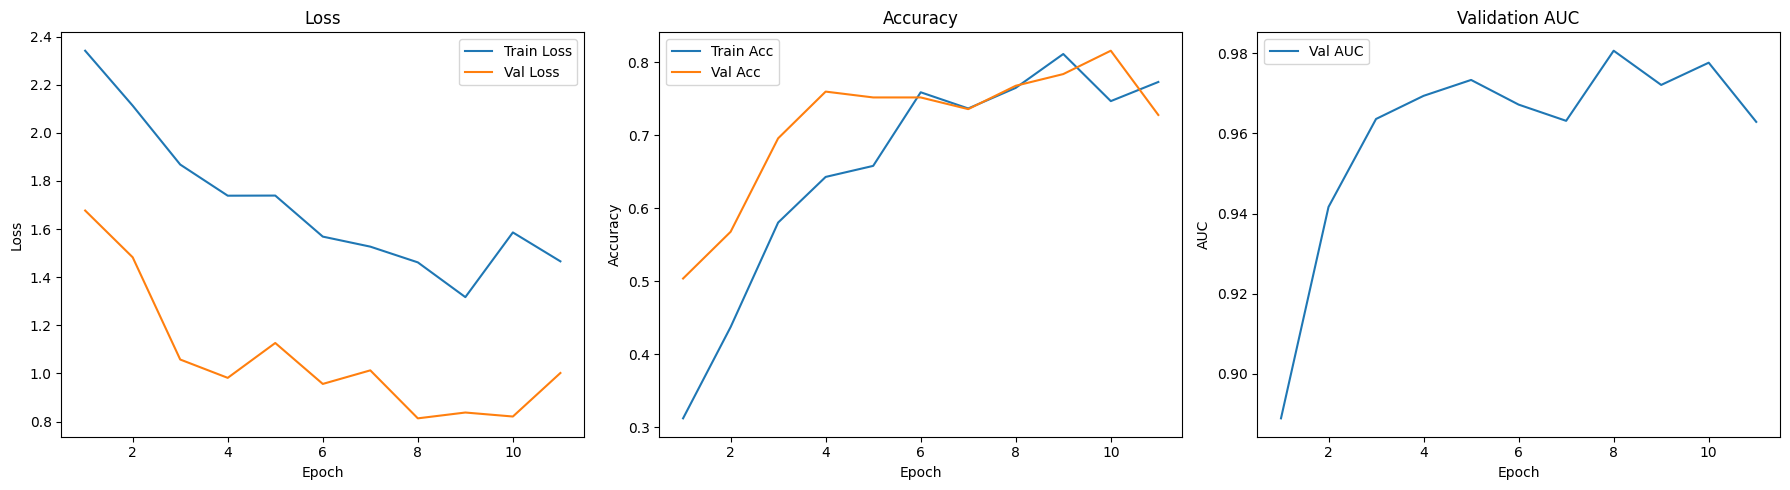

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\1561572985.py:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [21]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="vgg16", batch_size=32)



model_vgg16, history_vgg16 = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="vgg16",
    num_epochs=15,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_vgg16_ra_client.pth"
)

In [22]:
class_names = le.classes_

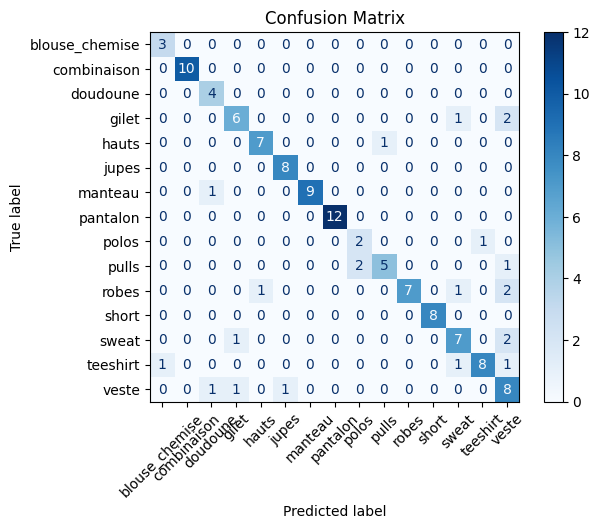

In [23]:
_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="vgg16", batch_size=32)


plot_confusion_matrix(model_vgg16, test_loader, class_names=class_names)

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="vgg16", batch_size=32)

evaluate_on_test(model_vgg16, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00        10
           2       0.67      1.00      0.80         4
           3       0.75      0.67      0.71         9
           4       0.88      0.88      0.88         8
           5       0.89      1.00      0.94         8
           6       1.00      0.90      0.95        10
           7       1.00      1.00      1.00        12
           8       0.50      0.67      0.57         3
           9       0.83      0.62      0.71         8
          10       1.00      0.64      0.78        11
          11       1.00      1.00      1.00         8
          12       0.70      0.70      0.70        10
          13       0.89      0.73      0.80        11
          14       0.50      0.73      0.59        11

    accuracy                           0.83       126
   macro avg       0.82      0.83      0.82       126


## GoogleNet

📿 Using device: cuda
Epoch 1/15 - Train Loss: 2.6537, Val Loss: 1.7205, Train Acc: 27.02%, Val Acc: 44.80%, AUC: 0.8787
📦 Best model saved.
Epoch 2/15 - Train Loss: 1.8984, Val Loss: 1.1430, Train Acc: 60.69%, Val Acc: 68.00%, AUC: 0.9355
📦 Best model saved.
Epoch 3/15 - Train Loss: 1.7235, Val Loss: 1.0146, Train Acc: 69.05%, Val Acc: 74.40%, AUC: 0.9579
📦 Best model saved.
Epoch 4/15 - Train Loss: 1.8547, Val Loss: 1.0528, Train Acc: 67.14%, Val Acc: 72.80%, AUC: 0.9616
Epoch 5/15 - Train Loss: 1.5714, Val Loss: 0.8949, Train Acc: 74.09%, Val Acc: 80.80%, AUC: 0.9745
📦 Best model saved.
Epoch 6/15 - Train Loss: 1.6960, Val Loss: 0.8740, Train Acc: 70.67%, Val Acc: 80.80%, AUC: 0.9749
📦 Best model saved.
Epoch 7/15 - Train Loss: 1.7003, Val Loss: 0.8614, Train Acc: 65.83%, Val Acc: 79.20%, AUC: 0.9769
📦 Best model saved.
Epoch 8/15 - Train Loss: 1.4309, Val Loss: 0.7186, Train Acc: 75.71%, Val Acc: 80.00%, AUC: 0.9816
📦 Best model saved.
Epoch 9/15 - Train Loss: 1.4807, Val Loss: 0.78

2025/08/28 14:50:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/28 14:50:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 11/15 - Train Loss: 1.4912, Val Loss: 0.7437, Train Acc: 80.54%, Val Acc: 83.20%, AUC: 0.9817
⏹️ Early stopping triggered.


2025/08/28 14:50:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 80.00%


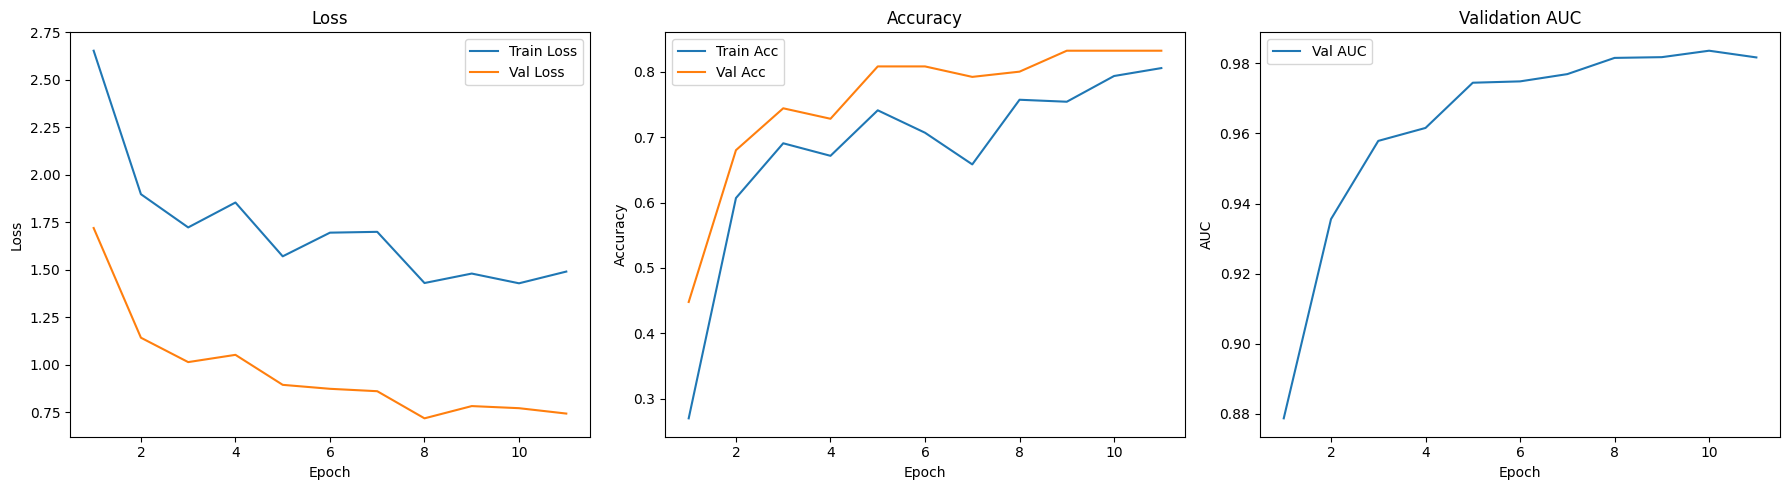

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\1561572985.py:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [25]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="inception_v3", batch_size=32)



model_googlenet, history_googlenet = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="inception_v3",
    num_epochs=15,
    lr=1e-4,
    device="cuda",
    early_stopping_patience=3,
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_googlenet_ra_client.pth"
);

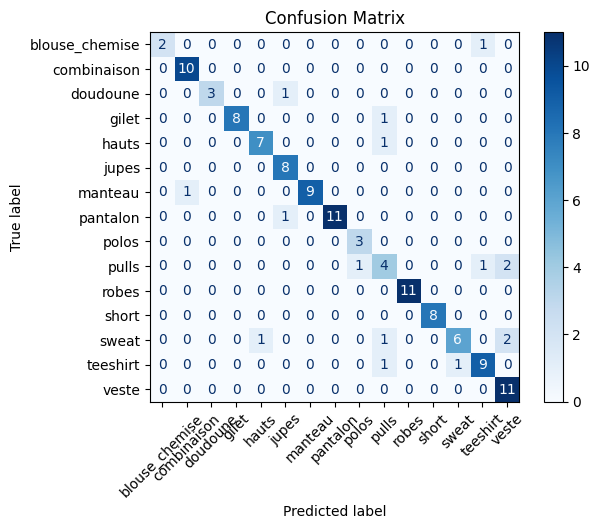

In [26]:
_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="inception_v3", batch_size=32)

plot_confusion_matrix(model_googlenet, test_loader, class_names=class_names)

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"


_, _,test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="inception_v3", batch_size=32)

evaluate_on_test(model_googlenet, test_loader, device)

📊 Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.91      1.00      0.95        10
           2       1.00      0.75      0.86         4
           3       1.00      0.89      0.94         9
           4       0.88      0.88      0.88         8
           5       0.80      1.00      0.89         8
           6       1.00      0.90      0.95        10
           7       1.00      0.92      0.96        12
           8       0.75      1.00      0.86         3
           9       0.50      0.50      0.50         8
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00         8
          12       0.86      0.60      0.71        10
          13       0.82      0.82      0.82        11
          14       0.73      1.00      0.85        11

    accuracy                           0.87       126
   macro avg       0.88      0.86      0.86       126


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\744664410.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./model/best_model_googlenet_

Image: 5_jai_standard_1753859165.5166833.png --> Prédiction : robes (50.44%)
Image: 44_jai_standard_1753861540.6951535.png --> Prédiction : teeshirt (24.88%)
Image: 8_jai_standard_1753859434.6211967.png --> Prédiction : hauts (34.34%)
Image: 30_jai_standard_1753861202.033563.png --> Prédiction : polos (15.16%)
Image: 41_jai_standard_1753861476.159126.png --> Prédiction : teeshirt (44.03%)
Image: 32_jai_standard_1753861255.300413.png --> Prédiction : robes (56.78%)


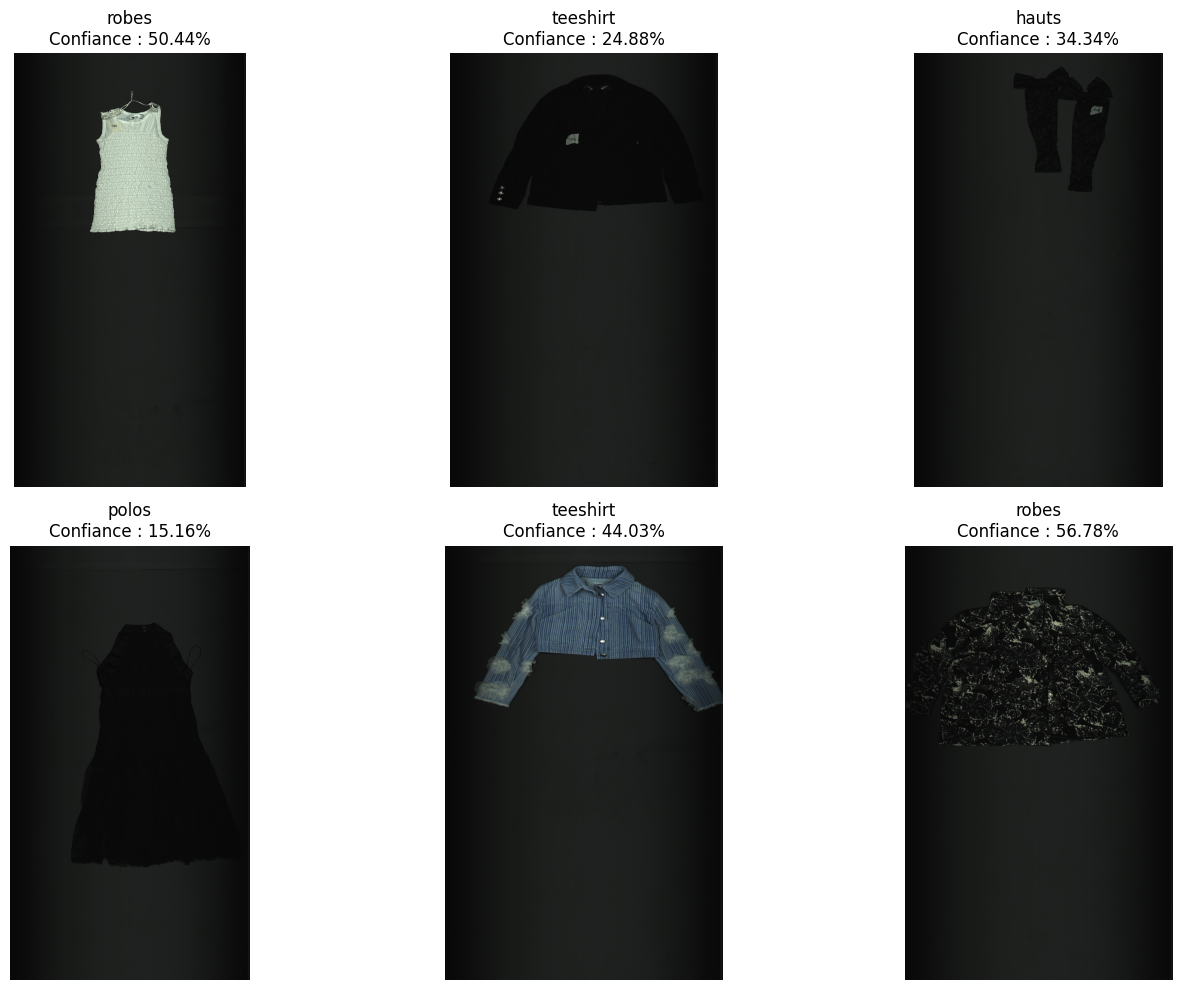

In [28]:
import os
import random
from PIL import Image
import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# === 1. Charger le modèle entraîné ===
model_name = "inception_v3"  # adapte si besoin
model = timm.create_model(model_name, pretrained=False, num_classes=len(le.classes_))

# Charger les poids
checkpoint = torch.load("./model/best_model_googlenet_ra_client.pth", map_location="cuda")
model.load_state_dict(checkpoint)

# Mettre sur CUDA et en mode évaluation
model.to("cuda")
model.eval()

# === 2. Appliquer les bonnes transformations recommandées par timm ===
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# === 3. Sélection de 6 images aléatoires ===
folder_path = "./lot_test"
all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(".png")]
random_images = random.sample(all_images, 6)

# === 4. Préparer la figure pour 2 lignes x 3 colonnes ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # pour itérer facilement

for ax, image_name in zip(axes, random_images):
    image_path = os.path.join(folder_path, image_name)
    image = Image.open(image_path).convert("RGB")
    
    # Prétraitement (via transform timm)
    input_tensor = transform(image).unsqueeze(0).to("cuda")

    # Prédiction
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)  # convertir en probabilités
        predicted_idx = output.argmax(dim=1).item()
        predicted_label = le.inverse_transform([predicted_idx])[0]
        confidence = probs[0, predicted_idx].item() * 100  # score en %

    # Console
    print(f"Image: {image_name} --> Prédiction : {predicted_label} ({confidence:.2f}%)")

    # Affichage matplotlib
    ax.imshow(image)
    ax.set_title(f"{predicted_label}\nConfiance : {confidence:.2f}%", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\1878145644.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./model/best_model_vgg16_ra_

Image: 34_jai_standard_1753861333.6166325.png --> Prédiction : jupes (85.74%)
Image: 0_jai_standard_1753859007.3713908.png --> Prédiction : manteau (54.17%)
Image: 3_jai_standard_1753859139.022341.png --> Prédiction : veste (54.22%)
Image: 28_jai_standard_1753861148.221416.png --> Prédiction : manteau (38.11%)
Image: 43_jai_standard_1753861507.9659362.png --> Prédiction : jupes (35.66%)
Image: 26_jai_standard_1753860925.0301137.png --> Prédiction : doudoune (22.66%)


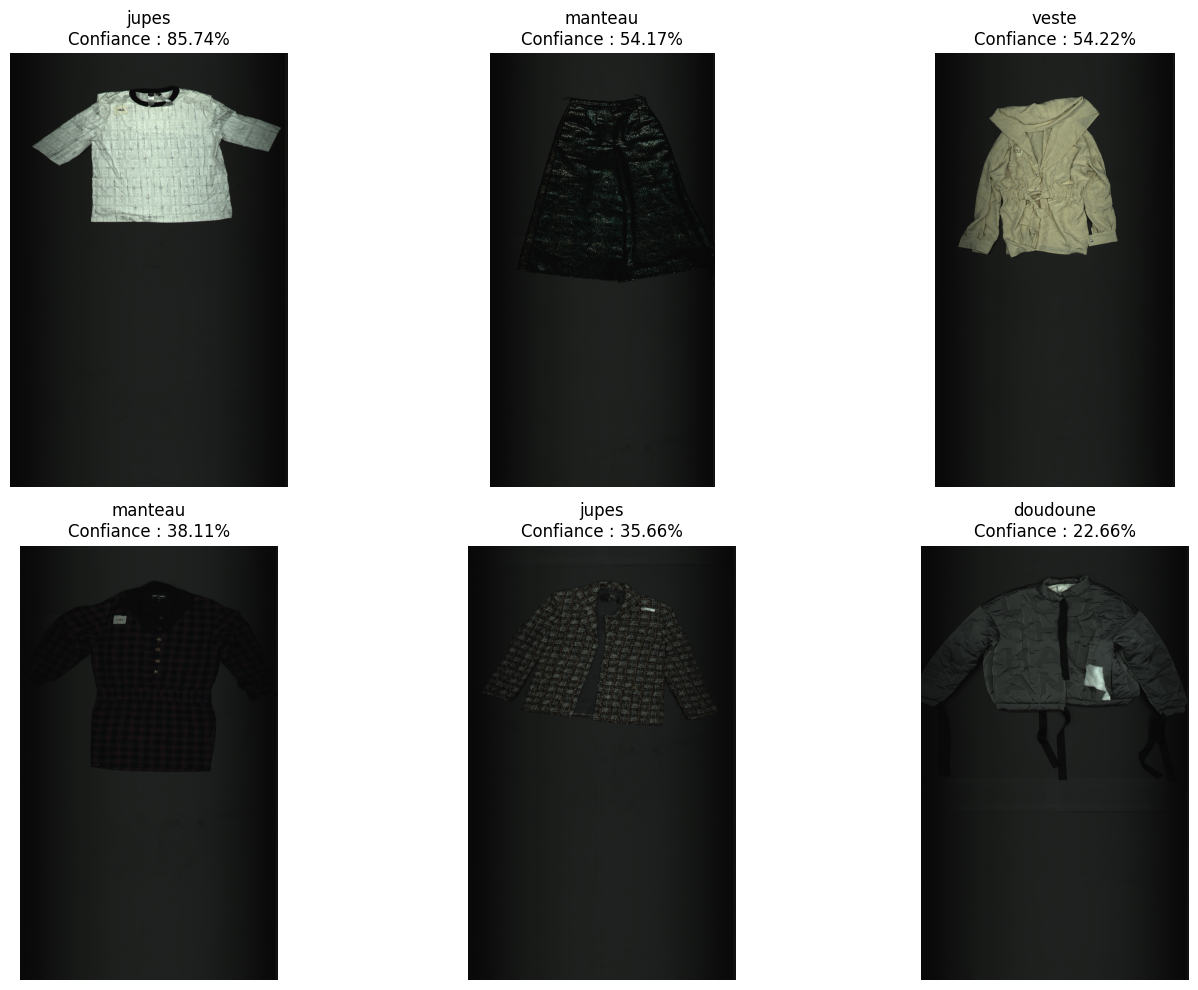

In [32]:
import os
import random
from PIL import Image
import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# === 1. Charger le modèle entraîné ===
model_name = "vgg16"  # adapte si besoin
model = timm.create_model(model_name, pretrained=False, num_classes=len(le.classes_))

# Charger les poids
checkpoint = torch.load("./model/best_model_vgg16_ra_client.pth", map_location="cuda")
model.load_state_dict(checkpoint)

# Mettre sur CUDA et en mode évaluation
model.to("cuda")
model.eval()

# === 2. Appliquer les bonnes transformations recommandées par timm ===
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# === 3. Sélection de 6 images aléatoires ===
folder_path = "./lot_test"
all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(".png")]
random_images = random.sample(all_images, 6)

# === 4. Préparer la figure pour 2 lignes x 3 colonnes ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # pour itérer facilement

for ax, image_name in zip(axes, random_images):
    image_path = os.path.join(folder_path, image_name)
    image = Image.open(image_path).convert("RGB")
    
    # Prétraitement (via transform timm)
    input_tensor = transform(image).unsqueeze(0).to("cuda")

    # Prédiction
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)  # convertir en probabilités
        predicted_idx = output.argmax(dim=1).item()
        predicted_label = le.inverse_transform([predicted_idx])[0]
        confidence = probs[0, predicted_idx].item() * 100  # score en %

    # Console
    print(f"Image: {image_name} --> Prédiction : {predicted_label} ({confidence:.2f}%)")

    # Affichage matplotlib
    ax.imshow(image)
    ax.set_title(f"{predicted_label}\nConfiance : {confidence:.2f}%", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [33]:
def train_model_with_plots(
    train_loader,
    val_loader,
    num_classes,
    model_name,
    num_epochs=10,
    lr=1e-4,
    device=None,
    mixup_fn=None,
    best_model_path="./model/best_model.pth"
):

    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("classification_vetements data augmentation")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📿 Using device: {device}")

    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Scheduler pour ajuster le LR si la val_loss stagne
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        verbose=True
    )

    best_val_loss = float("inf")
    best_val_acc = 0.0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_auc": []
    }

    with mlflow.start_run(run_name=f"{model_name}_run"):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("lr", lr)
        mlflow.log_param("epochs", num_epochs)

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                if mixup_fn is not None and images.size(0) % 2 == 0:
                    images, labels = mixup_fn(images, labels)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                targets = torch.argmax(labels, dim=1) if labels.ndim == 2 else labels
                correct += (preds == targets).sum().item()
                total += targets.size(0)

            train_loss = running_loss / total
            train_acc = correct / total
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)

            # Validation
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            all_labels = []
            all_probs = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    preds = torch.argmax(outputs, dim=1)
                    probs = torch.softmax(outputs, dim=1)

                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

                    all_labels.extend(labels.cpu().numpy())
                    all_probs.extend(probs.cpu().numpy())

            val_loss /= val_total
            val_acc = val_correct / val_total
            try:
                val_auc = roc_auc_score(all_labels, all_probs, multi_class="ovo")
            except:
                val_auc = 0.0

            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_auc"].append(val_auc)

            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc", train_acc, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_acc", val_acc, step=epoch)
            mlflow.log_metric("val_auc", val_auc, step=epoch)

            # Scheduler step
            scheduler.step(val_loss)

            print(f"Epoch {epoch + 1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc * 100:.2f}%, "
                  f"Val Acc: {val_acc * 100:.2f}%, "
                  f"AUC: {val_auc:.4f}, "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

            # Sauvegarde du meilleur modèle
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                torch.save(model.state_dict(), best_model_path)
                print("📦 Best model saved.")

        mlflow.pytorch.log_model(model, "model")

    print(f"\n🌝 Best Validation Accuracy: {best_val_acc * 100:.2f}%")
    plot_training_curves(history)

    model.load_state_dict(torch.load(best_model_path))
    return model, history


📿 Using device: cuda


c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 - Train Loss: 2.3524, Val Loss: 1.5090, Train Acc: 28.97%, Val Acc: 51.20%, AUC: 0.9207, LR: 0.000100
📦 Best model saved.
Epoch 2/20 - Train Loss: 1.9515, Val Loss: 1.1836, Train Acc: 53.75%, Val Acc: 60.80%, AUC: 0.9558, LR: 0.000100
📦 Best model saved.
Epoch 3/20 - Train Loss: 1.7944, Val Loss: 1.0457, Train Acc: 60.14%, Val Acc: 67.20%, AUC: 0.9694, LR: 0.000100
📦 Best model saved.
Epoch 4/20 - Train Loss: 1.8443, Val Loss: 1.2111, Train Acc: 68.33%, Val Acc: 72.00%, AUC: 0.9698, LR: 0.000100
Epoch 5/20 - Train Loss: 1.6372, Val Loss: 1.0507, Train Acc: 72.93%, Val Acc: 73.60%, AUC: 0.9698, LR: 0.000100
Epoch 6/20 - Train Loss: 1.6504, Val Loss: 1.2374, Train Acc: 69.63%, Val Acc: 72.80%, AUC: 0.9675, LR: 0.000050
Epoch 7/20 - Train Loss: 1.5565, Val Loss: 0.8017, Train Acc: 77.02%, Val Acc: 80.80%, AUC: 0.9782, LR: 0.000050
📦 Best model saved.
Epoch 8/20 - Train Loss: 1.3486, Val Loss: 0.7608, Train Acc: 81.62%, Val Acc: 79.20%, AUC: 0.9794, LR: 0.000050
📦 Best model sav

2025/08/28 19:40:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 20/20 - Train Loss: 1.3321, Val Loss: 0.6888, Train Acc: 82.72%, Val Acc: 85.60%, AUC: 0.9827, LR: 0.000006


2025/08/28 19:40:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/08/28 19:40:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 84.00%


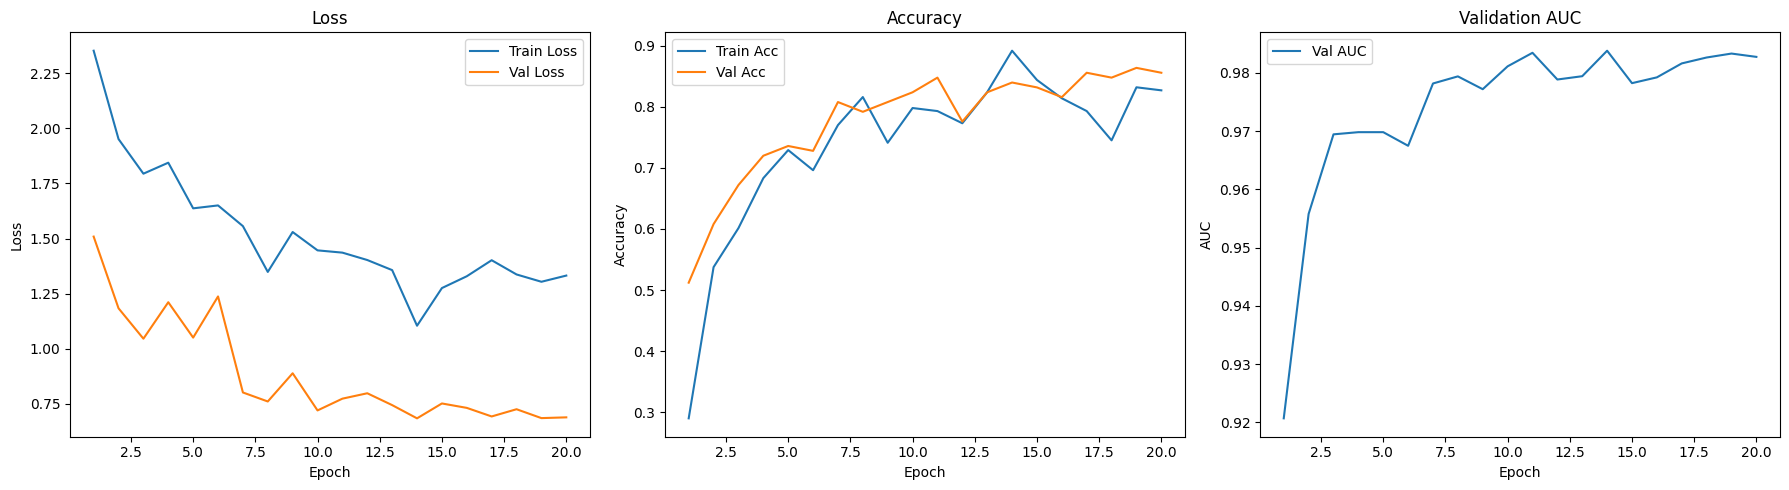

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\3803903645.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [34]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="vgg16", batch_size=32)



model_vgg16, history_vgg16 = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="vgg16",
    num_epochs=20,
    lr=1e-4,
    device="cuda",
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_vgg16_ra_client_lr.pth"
)

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\1621055518.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./model/best_model_vgg16_ra_

Image: 7_jai_standard_1753859406.0604253.png --> Prédiction : combinaison (46.28%)
Image: 24_jai_standard_1753860791.9715614.png --> Prédiction : jupes (75.54%)
Image: 27_jai_standard_1753861121.1850736.png --> Prédiction : hauts (18.67%)
Image: 32_jai_standard_1753861255.300413.png --> Prédiction : robes (27.21%)
Image: 23_jai_standard_1753860774.5011373.png --> Prédiction : manteau (23.63%)
Image: 11_jai_standard_1753860161.103029.png --> Prédiction : pantalon (72.24%)


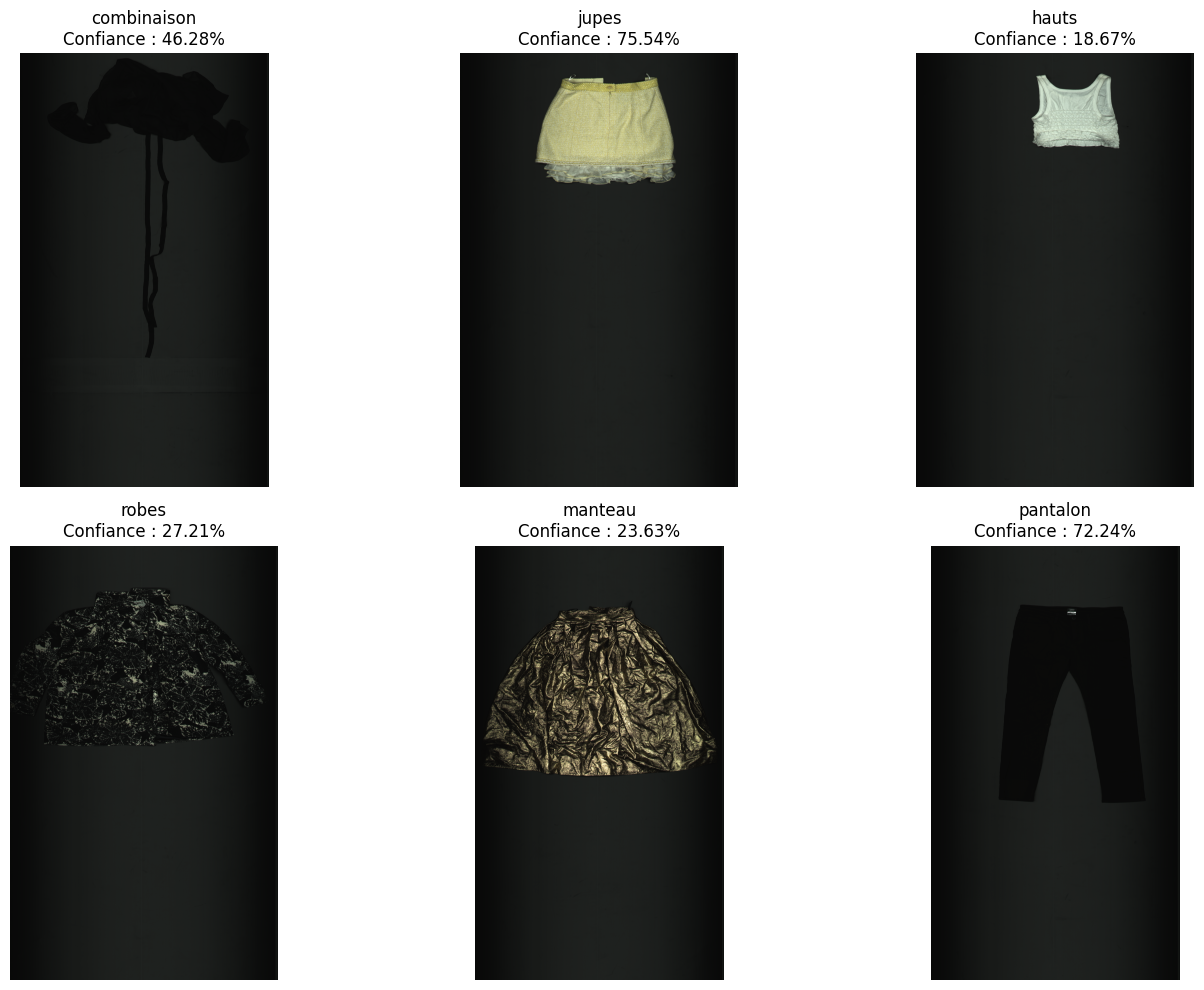

In [37]:
import os
import random
from PIL import Image
import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# === 1. Charger le modèle entraîné ===
model_name = "vgg16"  # adapte si besoin
model = timm.create_model(model_name, pretrained=False, num_classes=len(le.classes_))

# Charger les poids
checkpoint = torch.load("./model/best_model_vgg16_ra_client_lr.pth", map_location="cuda")
model.load_state_dict(checkpoint)

# Mettre sur CUDA et en mode évaluation
model.to("cuda")
model.eval()

# === 2. Appliquer les bonnes transformations recommandées par timm ===
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# === 3. Sélection de 6 images aléatoires ===
folder_path = "./lot_test"
all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(".png")]
random_images = random.sample(all_images, 6)

# === 4. Préparer la figure pour 2 lignes x 3 colonnes ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # pour itérer facilement

for ax, image_name in zip(axes, random_images):
    image_path = os.path.join(folder_path, image_name)
    image = Image.open(image_path).convert("RGB")
    
    # Prétraitement (via transform timm)
    input_tensor = transform(image).unsqueeze(0).to("cuda")

    # Prédiction
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)  # convertir en probabilités
        predicted_idx = output.argmax(dim=1).item()
        predicted_label = le.inverse_transform([predicted_idx])[0]
        confidence = probs[0, predicted_idx].item() * 100  # score en %

    # Console
    print(f"Image: {image_name} --> Prédiction : {predicted_label} ({confidence:.2f}%)")

    # Affichage matplotlib
    ax.imshow(image)
    ax.set_title(f"{predicted_label}\nConfiance : {confidence:.2f}%", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


📿 Using device: cuda


c:\Users\BureauCETIA\Desktop\Travaux_cetia_Yann\CETIA_Idclothes\clothes_class_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 - Train Loss: 2.7114, Val Loss: 1.4758, Train Acc: 29.07%, Val Acc: 53.60%, AUC: 0.9189, LR: 0.000100
📦 Best model saved.
Epoch 2/20 - Train Loss: 2.0915, Val Loss: 1.6133, Train Acc: 47.15%, Val Acc: 52.00%, AUC: 0.9046, LR: 0.000100
Epoch 3/20 - Train Loss: 1.9411, Val Loss: 1.0505, Train Acc: 56.34%, Val Acc: 75.20%, AUC: 0.9592, LR: 0.000100
📦 Best model saved.
Epoch 4/20 - Train Loss: 1.6916, Val Loss: 0.9595, Train Acc: 72.63%, Val Acc: 76.00%, AUC: 0.9643, LR: 0.000100
📦 Best model saved.
Epoch 5/20 - Train Loss: 1.8266, Val Loss: 0.8849, Train Acc: 60.44%, Val Acc: 82.40%, AUC: 0.9752, LR: 0.000100
📦 Best model saved.
Epoch 6/20 - Train Loss: 1.5460, Val Loss: 0.7305, Train Acc: 72.53%, Val Acc: 80.80%, AUC: 0.9792, LR: 0.000100
📦 Best model saved.
Epoch 7/20 - Train Loss: 1.5305, Val Loss: 0.7451, Train Acc: 75.72%, Val Acc: 83.20%, AUC: 0.9805, LR: 0.000100
Epoch 8/20 - Train Loss: 1.5523, Val Loss: 0.7322, Train Acc: 74.93%, Val Acc: 80.80%, AUC: 0.9792, LR: 0.000

2025/08/28 22:33:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/28 22:33:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 20/20 - Train Loss: 1.3175, Val Loss: 0.5858, Train Acc: 80.42%, Val Acc: 85.60%, AUC: 0.9915, LR: 0.000025


2025/08/28 22:33:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🌝 Best Validation Accuracy: 86.40%


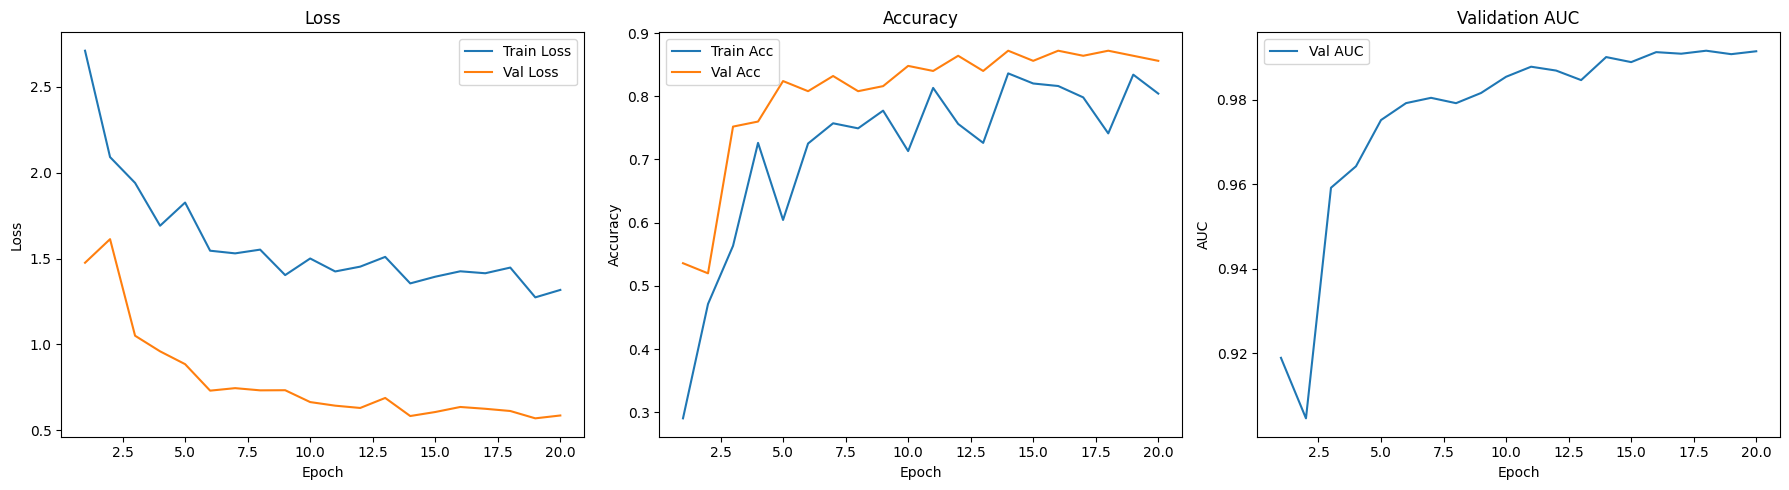

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\3803903645.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [35]:
train_loader, val_loader, test_loader = create_data_loaders_ra_from_df(idclothes_df_client, model_name="inception_v3", batch_size=32)



model_googlenet, history_googlenet = train_model_with_plots(
    train_loader, val_loader,
    num_classes=len(le.classes_),
    model_name="inception_v3",
    num_epochs=20,
    lr=1e-4,
    device="cuda",
    mixup_fn=mixup_fn,
    best_model_path= "./model/best_model_googlenet_ra_client_lr.pth"
)

C:\Users\BureauCETIA\AppData\Local\Temp\ipykernel_18064\3167076571.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./model/best_model_googlenet

Image: 3_jai_standard_1753859139.022341.png --> Prédiction : veste (14.81%)
Image: 35_jai_standard_1753861343.821201.png --> Prédiction : hauts (49.34%)
Image: 24_jai_standard_1753860791.9715614.png --> Prédiction : jupes (39.64%)
Image: 36_jai_standard_1753861368.420142.png --> Prédiction : robes (30.09%)
Image: 22_jai_standard_1753860723.9618497.png --> Prédiction : jupes (64.27%)
Image: 1_jai_standard_1753859094.538679.png --> Prédiction : hauts (24.93%)


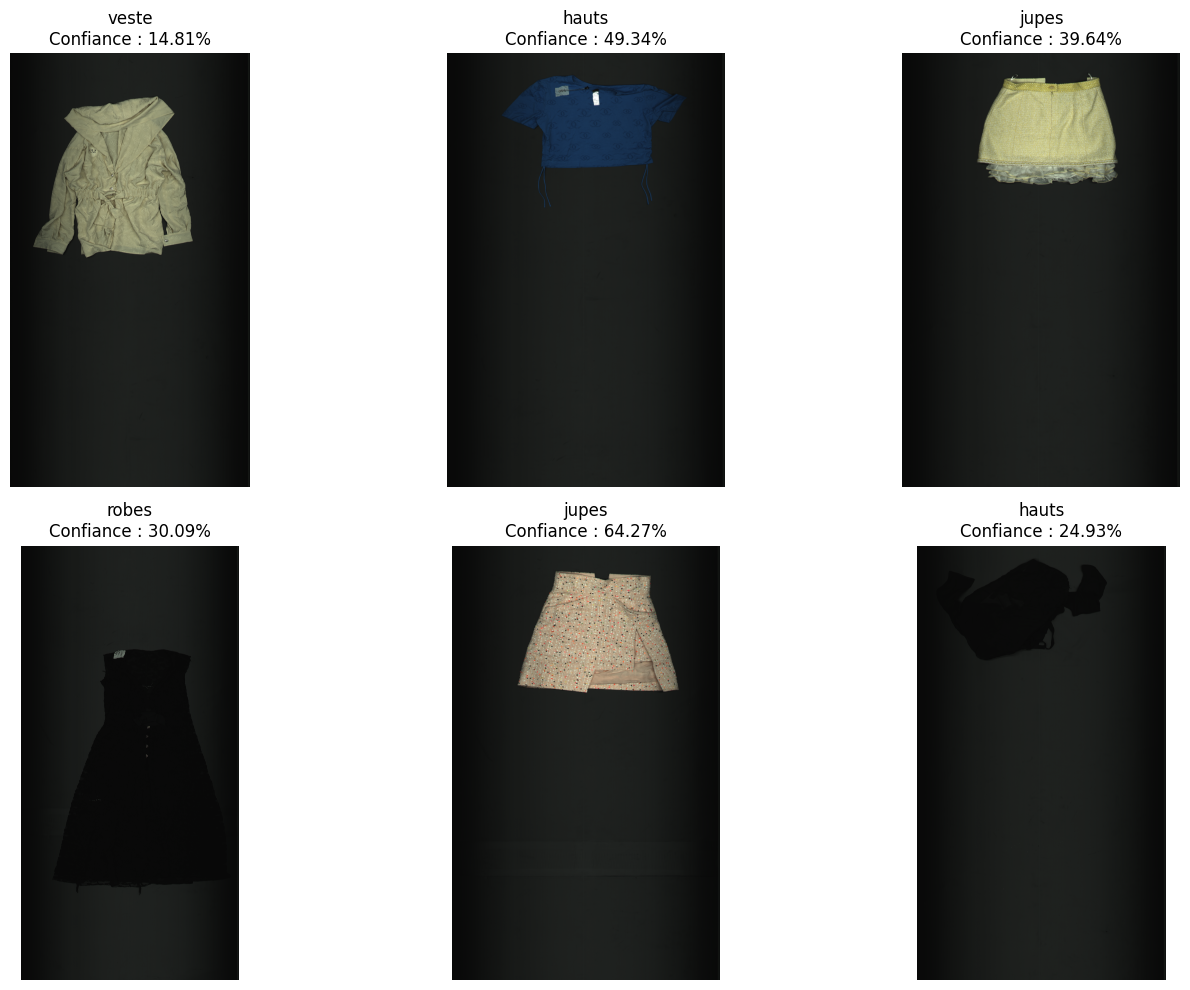

In [41]:
import os
import random
from PIL import Image
import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# === 1. Charger le modèle entraîné ===
model_name = "inception_v3"  # adapte si besoin
model = timm.create_model(model_name, pretrained=False, num_classes=len(le.classes_))

# Charger les poids
checkpoint = torch.load("./model/best_model_googlenet_ra_client_lr.pth", map_location="cuda")
model.load_state_dict(checkpoint)

# Mettre sur CUDA et en mode évaluation
model.to("cuda")
model.eval()

# === 2. Appliquer les bonnes transformations recommandées par timm ===
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# === 3. Sélection de 6 images aléatoires ===
folder_path = "./lot_test"
all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(".png")]
random_images = random.sample(all_images, 6)

# === 4. Préparer la figure pour 2 lignes x 3 colonnes ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # pour itérer facilement

for ax, image_name in zip(axes, random_images):
    image_path = os.path.join(folder_path, image_name)
    image = Image.open(image_path).convert("RGB")
    
    # Prétraitement (via transform timm)
    input_tensor = transform(image).unsqueeze(0).to("cuda")

    # Prédiction
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)  # convertir en probabilités
        predicted_idx = output.argmax(dim=1).item()
        predicted_label = le.inverse_transform([predicted_idx])[0]
        confidence = probs[0, predicted_idx].item() * 100  # score en %

    # Console
    print(f"Image: {image_name} --> Prédiction : {predicted_label} ({confidence:.2f}%)")

    # Affichage matplotlib
    ax.imshow(image)
    ax.set_title(f"{predicted_label}\nConfiance : {confidence:.2f}%", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()
